In [1]:
import os
from typing import Callable, Optional, Sequence, List, Dict, Any

import numpy as np
import pandas as pd

# =========================
# 1) Feature blocks to keep
# =========================
B0_SUMMARY = []

B0_TURNS = [
    "words_per_min",
    "speech_percentage",
    "mean_pause_length",
    "pause_variability",
    "word_repeat_percentage",
    "phrase_repeat_percentage",
    "turn_length_words",
]

# ---- L: language-dependent ----
L_SUMMARY = [
    "word_coherence_mean",
    "word_coherence_10_mean",
    "semantic_perplexity_mean",
    "semantic_perplexity_5_mean",
    "first_order_sentence_tangeniality_mean",
]

L_TURNS = [
    "syllables_per_min",
    "sentiment_neg",
    "sentiment_pos",
    "sentiment_overall",
    "mattr_10",
    "mattr_50",
    "first_person_percentage",
    "first_person_sentiment_negative",
]
LANGUAGE = "ukr" # "ukr"
ITERATION = '3'

# =========================
# 2) One function (similar to yours)
# =========================

def _unique_preserve_order(items: Sequence[str]) -> List[str]:
    seen = set()
    out = []
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def merge_turns_and_summary_featureblock(
    detailed_labels_path: str,
    data_dir: str,
    *,
    participant_col: str = "Participant",
    turns_cols: Optional[List[str]] = None,
    summary_cols: Optional[List[str]] = None,
    turns_prefix: str = "turns_",
    summary_prefix: str = "summary_sc_",
    turns_suffix: str = ".csv",
    summary_suffix: str = ".csv",
    turns_agg: str | Callable[[pd.Series], Any] = "mean",   # "mean" | "first" | callable
    resolve_name_collisions: bool = True,                  # prevent overwriting when col exists in both
    turns_collision_suffix: str = "_turns",
    summary_collision_suffix: str = "_summary",
    # optional: if your turns files still include speaker rows, set these
    turns_speaker_col: Optional[str] = None,               # e.g. "speaker_label"
    participant_speaker_value: Optional[str] = None,       # e.g. "Participant"
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Merge specified feature columns from turns_<pid>.csv and summary_sc_<pid>.csv into the labels table.
    - Aggregates turns columns per participant (default: mean).
    - Takes summary columns from the first row (file-level).
    - Resolves name collisions by suffixing if requested.
    """
    if os.path.isfile(data_dir):
        data_dir = os.path.dirname(data_dir)
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Directory not found: {data_dir}")

    df_labels = pd.read_csv(detailed_labels_path)
    df_labels[participant_col] = pd.to_numeric(df_labels[participant_col], errors="coerce").astype("Int64")

    pids = df_labels[participant_col].dropna().unique().astype(int)

    # keep list order stable, remove duplicates
    turns_cols = _unique_preserve_order(turns_cols or [])
    summary_cols = _unique_preserve_order(summary_cols or [])

    rows: List[Dict[str, Any]] = []
    for pid in pids:
        rec: Dict[str, Any] = {participant_col: pid}

        # ---------- turns_<pid>.csv ----------
        t_path = os.path.join(data_dir, f"{turns_prefix}{pid}{turns_suffix}")
        if os.path.exists(t_path) and turns_cols:
            t_header = pd.read_csv(t_path, nrows=0).columns.tolist()
            t_use = [c for c in turns_cols if c in t_header]

            # ensure speaker column is included if filtering is requested
            if turns_speaker_col and turns_speaker_col in t_header and turns_speaker_col not in t_use:
                t_use_with_speaker = [turns_speaker_col] + t_use
            else:
                t_use_with_speaker = t_use

            if t_use:
                t_df = pd.read_csv(t_path, usecols=t_use_with_speaker)

                # optional speaker filtering
                if turns_speaker_col and participant_speaker_value is not None and turns_speaker_col in t_df.columns:
                    t_df = t_df[t_df[turns_speaker_col] == participant_speaker_value].copy()

                # aggregate
                t_vals: Dict[str, Any] = {}
                if callable(turns_agg):
                    for c in t_use:
                        t_vals[c] = turns_agg(t_df[c])
                elif turns_agg == "mean":
                    for c in t_use:
                        col = pd.to_numeric(t_df[c], errors="coerce")
                        t_vals[c] = float(col.mean()) if len(col) else np.nan
                elif turns_agg == "first":
                    for c in t_use:
                        t_vals[c] = t_df[c].iloc[0] if len(t_df) else np.nan
                else:
                    raise ValueError(f"Unsupported turns_agg: {turns_agg!r}")

                # collision-safe naming (prevents overwriting later)
                if resolve_name_collisions:
                    renamed = {}
                    for k, v in t_vals.items():
                        out_k = k if k not in rec else f"{k}{turns_collision_suffix}"
                        renamed[out_k] = v
                    t_vals = renamed

                rec.update(t_vals)
            elif verbose:
                print(f"[pid={pid}] turns file exists but none of requested cols found.")

        # ---------- summary_sc_<pid>.csv ----------
        s_path = os.path.join(data_dir, f"{summary_prefix}{pid}{summary_suffix}")
        if os.path.exists(s_path) and summary_cols:
            s_header = pd.read_csv(s_path, nrows=0).columns.tolist()
            s_use = [c for c in summary_cols if c in s_header]
            if s_use:
                s_df = pd.read_csv(s_path, usecols=s_use)
                s_vals = {c: (s_df[c].iloc[0] if len(s_df) else np.nan) for c in s_use}

                # collision-safe naming
                if resolve_name_collisions:
                    renamed = {}
                    for k, v in s_vals.items():
                        out_k = k if k not in rec else f"{k}{summary_collision_suffix}"
                        renamed[out_k] = v
                    s_vals = renamed

                rec.update(s_vals)
            elif verbose:
                print(f"[pid={pid}] summary file exists but none of requested cols found.")

        rows.append(rec)

    df_feat = pd.DataFrame(rows)
    df_out = df_labels.merge(df_feat, on=participant_col, how="left")
    return df_out

# =========================
# 3) Build 3 datasets by calling the same function
# =========================

def _union(a: List[str], b: List[str]) -> List[str]:
    return _unique_preserve_order(list(a) + list(b))

In [2]:


# Paths (edit)
detailed_labels_path = "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/detailed_lables.csv"
data_dir = f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/result_oppenwillis_{LANGUAGE}_norm_gemma"

# Columns you always want in the final CSVs (spine)
SPINE_COLS = ["Participant", "gender", "age", "split", "Depression_label", "PTSD_label", "PTSD_severity", "Depression_severity"]

# --- L ---
df_l = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=L_TURNS,
    summary_cols=L_SUMMARY,
    turns_agg="mean",
    resolve_name_collisions=True,
)

L_OUT_COLS = [c for c in df_l.columns if c in SPINE_COLS] + \
            [c for c in df_l.columns if (c in L_TURNS or c.endswith("_turns"))] + \
            [c for c in df_l.columns if (c in L_SUMMARY or c.endswith("_summary"))]

df_l_out = df_l[_unique_preserve_order(L_OUT_COLS)].copy()
df_l_out.to_csv(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_{LANGUAGE}_small_test{ITERATION}.csv",
    index=False
)
print("df_l columns - ", df_l_out.columns)

# --- B0 ---
df_b0 = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=B0_TURNS,
    summary_cols=B0_SUMMARY,
    turns_agg="mean",
    resolve_name_collisions=True,  # keeps both turns+summary if same name exists
)

b0_feature_cols = _unique_preserve_order(
    [c for c in df_b0.columns if c not in df_b0.columns.difference(df_b0.columns)]  # noop, keep below
)
# safer: explicitly compute expected output cols by checking presence
B0_OUT_COLS = [c for c in df_b0.columns if c in SPINE_COLS] + \
             [c for c in df_b0.columns if (c in B0_TURNS or c.endswith("_turns"))] + \
             [c for c in df_b0.columns if (c in B0_SUMMARY or c.endswith("_summary"))]

df_b0_out = df_b0[_unique_preserve_order(B0_OUT_COLS)].copy()
df_b0_out.to_csv(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_{LANGUAGE}_small_test{ITERATION}.csv",
    index=False
)
print("df_b0 columns - ", df_b0_out.columns)

# --- B0 + L ---
df_b0l = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=_union(B0_TURNS, L_TURNS),
    summary_cols=_union(B0_SUMMARY, L_SUMMARY),
    turns_agg="mean",
    resolve_name_collisions=True,
)

B0L_OUT_COLS = [c for c in df_b0l.columns if c in SPINE_COLS] + \
              [c for c in df_b0l.columns if (c in _union(B0_TURNS, L_TURNS) or c.endswith("_turns"))] + \
              [c for c in df_b0l.columns if (c in _union(B0_SUMMARY, L_SUMMARY) or c.endswith("_summary"))]

df_b0l_out = df_b0l[_unique_preserve_order(B0L_OUT_COLS)].copy()
df_b0l_out.to_csv(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_{LANGUAGE}_full{ITERATION}.csv",
    index=False
)
print("df l+b0 columns ", df_b0l_out.columns)

df_l columns -  Index(['Participant', 'Depression_severity', 'PTSD_severity', 'gender', 'age',
       'Depression_label', 'PTSD_label', 'split', 'syllables_per_min',
       'sentiment_neg', 'sentiment_pos', 'sentiment_overall', 'mattr_10',
       'mattr_50', 'first_person_percentage',
       'first_person_sentiment_negative', 'word_coherence_mean',
       'word_coherence_10_mean', 'semantic_perplexity_mean',
       'semantic_perplexity_5_mean', 'first_order_sentence_tangeniality_mean'],
      dtype='object')
df_b0 columns -  Index(['Participant', 'Depression_severity', 'PTSD_severity', 'gender', 'age',
       'Depression_label', 'PTSD_label', 'split', 'words_per_min',
       'speech_percentage', 'mean_pause_length', 'pause_variability',
       'word_repeat_percentage', 'phrase_repeat_percentage',
       'turn_length_words'],
      dtype='object')
df l+b0 columns  Index(['Participant', 'Depression_severity', 'PTSD_severity', 'gender', 'age',
       'Depression_label', 'PTSD_label', 'spl

In [3]:
import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Sequence, Dict, Any, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, brier_score_loss, classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, cross_val_score

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
xgb_available = True


# -------------------------
# Bootstrap CIs
# -------------------------
def bootstrap_ci_binary(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    metric: str,
    n_boot: int = 2000,
    seed: int = 1706,
    stratified: bool = True,
) -> Tuple[float, float, float]:
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]
    if len(idx_pos) == 0 or len(idx_neg) == 0:
        return float("nan"), float("nan"), float("nan")

    scores = []
    for _ in range(n_boot):
        if stratified:
            samp_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
            samp_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
            idx = np.concatenate([samp_pos, samp_neg])
        else:
            idx = rng.choice(len(y_true), size=len(y_true), replace=True)

        yt, yp, pr = y_true[idx], y_pred[idx], y_proba[idx]
        if metric == "f1_macro":
            s = f1_score(yt, yp, average="macro")
        elif metric == "auc":
            if len(np.unique(yt)) < 2:
                continue
            s = roc_auc_score(yt, pr)
        else:
            raise ValueError("metric must be 'f1_macro' or 'auc'")
        scores.append(s)

    if not scores:
        return float("nan"), float("nan"), float("nan")

    lo, hi = np.percentile(scores, [2.5, 97.5])
    return float(np.mean(scores)), float(lo), float(hi)


# -------------------------
# Standardized leakage-safe drop builder
# -------------------------
def build_standard_drop_cols(
    df: pd.DataFrame,
    *,
    target_col: str,
    split_col: str = "split",
    id_col: str = "Participant",
    drop_demographics: bool = True,
    extra_drop: Optional[Sequence[str]] = None,
) -> List[str]:
    """
    Стандартизированный drop для бинарного таргета:
      - всегда: id_col, split_col, target_col
      - всегда: все *_label кроме target_col
      - всегда: все колонки с 'severity' в имени (любой таргет)
      - опционально: age/sex/gender
      - + extra_drop (если передано)
    """
    drop = set()

    # base/meta
    for c in [id_col, split_col, target_col]:
        if c in df.columns:
            drop.add(c)

    # labels (avoid "other ground-truth labels" leakage)
    for c in df.columns:
        cl = c.lower()
        if cl.endswith("_label") and c != target_col:
            drop.add(c)

    # severity-like columns (avoid "target proxy" leakage)
    for c in df.columns:
        if "severity" in c.lower():
            drop.add(c)

    # demographics (optional)
    if drop_demographics:
        for c in ["age", "sex", "gender"]:
            if c in df.columns:
                drop.add(c)

    if extra_drop:
        for c in extra_drop:
            if c in df.columns:
                drop.add(c)

    return sorted(drop)


def assert_no_leakage_cols_left(X: pd.DataFrame) -> None:
    bad = []
    for c in X.columns:
        cl = c.lower()
        if cl.endswith("_label") or "severity" in cl or cl == "split":
            bad.append(c)
    if bad:
        raise ValueError(
            "Leakage columns detected in features X (you must drop them): "
            + ", ".join(sorted(set(bad)))
        )


# -------------------------
# Main pipeline
# -------------------------
def run_models_pipeline_more_models_tuned_prauc(
    dataset_path: str,
    *,
    target_col: str = "Depression_label",
    split_col: str = "split",
    id_col: str = "Participant",
    train_values: Sequence[str] = ("train", "dev"),
    test_value: str = "test",

    # If provided -> used as EXTRA drops in addition to standardized drops.
    drop_cols: Optional[Sequence[str]] = None,

    # Standardization controls
    drop_demographics: bool = True,

    random_state: int = 1706,
    n_boot: int = 2000,

    compute_importance: bool = True,
    perm_scoring: str = "average_precision",
    perm_n_repeats: int = 10,
    plot_top_k: int = 15,

    # train-only feature selection
    train_on_importance: bool = True,
    importance_top_k: int = 5,
    importance_corr_thr: float = 0.90,
    importance_n_repeats: int = 20,
    importance_cv_splits: int = 5,

    # grid search for tree-based models
    tune_tree_models: bool = True,
    cv_splits: int = 5,
    grid_scoring: str = "average_precision",
    grid_n_jobs: int = 1,
    grid_verbose: int = 0,

    # report CV AUC for ALL models on train+dev
    report_train_cv_pr_auc: bool = True,
) -> pd.DataFrame:
    """
    Standardized version: drop_cols is automatically constructed from the selected target_col,
    so that there are no leaks (other *_label, severity, split, id).
    """

    df = pd.read_csv(dataset_path)

    if split_col not in df.columns:
        raise KeyError(f"Missing '{split_col}' column in dataset: {dataset_path}")
    if target_col not in df.columns:
        raise KeyError(f"Missing target_col='{target_col}' in dataset: {dataset_path}")

    # --- build standardized drops ---
    std_drop = build_standard_drop_cols(
        df,
        target_col=target_col,
        split_col=split_col,
        id_col=id_col,
        drop_demographics=drop_demographics,
        extra_drop=drop_cols,
    )

    # --- split ---
    split_lower = df[split_col].astype(str).str.lower().str.strip()
    train_values_set = {str(v).lower() for v in train_values}
    is_train = split_lower.isin(train_values_set)
    is_test = split_lower.eq(str(test_value).lower())

    if is_train.sum() == 0 or is_test.sum() == 0:
        raise ValueError(
            f"Train/Test rows not found. train in {sorted(train_values_set)} count={is_train.sum()}, "
            f"test='{test_value}' count={is_test.sum()}."
        )

    # --- y ---
    y_train = df.loc[is_train, target_col].astype(int).to_numpy()
    y_test = df.loc[is_test, target_col].astype(int).to_numpy()

    # sanity: binary
    uniq = np.unique(y_train)
    if len(uniq) != 2:
        raise ValueError(f"Target '{target_col}' is not binary on train+dev. Unique values: {uniq}")

    # --- X ---
    X_train = df.loc[is_train].drop(columns=std_drop, errors="ignore")
    X_test = df.loc[is_test].drop(columns=std_drop, errors="ignore")

    if X_train.shape[1] == 0:
        raise ValueError("No features left after dropping standardized leakage/meta columns.")

    # hard guard: make sure nothing leaky stayed
    assert_no_leakage_cols_left(X_train)

    # -------------------------
    # helpers
    # -------------------------
    def _build_preprocessor(X: pd.DataFrame) -> Tuple[ColumnTransformer, List[str], List[str]]:
        categorical_cols = [c for c in X.columns if X[c].dtype.name in ["object", "category", "bool"]]
        numeric_cols = [c for c in X.columns if c not in categorical_cols]

        try:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

        cat_pipe = Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("enc", ohe),
        ])
        num_pipe = Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ])

        pre = ColumnTransformer(
            transformers=[
                ("cat", cat_pipe, categorical_cols),
                ("num", num_pipe, numeric_cols),
            ],
            remainder="drop"
        )
        return pre, categorical_cols, numeric_cols

    def _predict_proba_or_score(pipe: Pipeline, X: pd.DataFrame) -> Optional[np.ndarray]:
        try:
            return pipe.predict_proba(X)[:, 1]
        except Exception:
            try:
                from scipy.special import expit
                return expit(pipe.decision_function(X))
            except Exception:
                return None

    def _metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: Optional[np.ndarray]) -> Dict[str, Any]:
        out = {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
            "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
            "roc_auc": float("nan"),
            "pr_auc": float("nan"),
            "brier": float("nan"),
            "f1_lo": float("nan"),
            "f1_hi": float("nan"),
            "auc_lo": float("nan"),
            "auc_hi": float("nan"),
        }
        if y_proba is not None and len(np.unique(y_true)) == 2:
            out["roc_auc"] = float(roc_auc_score(y_true, y_proba))
            out["pr_auc"] = float(average_precision_score(y_true, y_proba))
            out["brier"] = float(brier_score_loss(y_true, y_proba))

            _, f1_lo, f1_hi = bootstrap_ci_binary(y_true, y_pred, y_proba, metric="f1_macro", n_boot=n_boot, seed=random_state)
            _, auc_lo, auc_hi = bootstrap_ci_binary(y_true, y_pred, y_proba, metric="auc", n_boot=n_boot, seed=random_state)
            out["f1_lo"], out["f1_hi"] = float(f1_lo), float(f1_hi)
            out["auc_lo"], out["auc_hi"] = float(auc_lo), float(auc_hi)
        return out

    def _safe_cv_splits(y: np.ndarray, desired: int) -> int:
        counts = Counter(y.tolist())
        min_class = min(counts.values()) if counts else 0
        return max(2, min(desired, min_class)) if min_class >= 2 else 0

    def _cv_pr_auc(pipe: Pipeline, X: pd.DataFrame, y: np.ndarray, desired_splits: int) -> Tuple[float, float]:
        k = _safe_cv_splits(y, desired_splits)
        if k < 2:
            return float("nan"), float("nan")
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        scores = cross_val_score(clone(pipe), X, y, cv=cv, scoring="average_precision", n_jobs=1)
        return float(np.mean(scores)), float(np.std(scores))

    def _warn_if_degenerate_proba(y_proba: Optional[np.ndarray], title: str) -> None:
        if y_proba is None:
            return
        uniqp = np.unique(np.round(y_proba, 6))
        if len(uniqp) <= 5:
            print(f"[WARN] {title}: very few unique predicted probabilities ({len(uniqp)}).")

    def _perm_importance_raw(pipe: Pipeline, X_eval: pd.DataFrame, y_eval: np.ndarray, title: str) -> None:
        try:
            perm = permutation_importance(
                pipe, X_eval, y_eval,
                n_repeats=perm_n_repeats,
                random_state=random_state,
                scoring=perm_scoring
            )
            perm_df = pd.DataFrame({
                "feature": list(X_eval.columns),
                "importance_mean": perm.importances_mean,
                "importance_std": perm.importances_std,
            }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

            print(f"\n[{title}] Top-{min(10, len(perm_df))} permutation importances ({perm_scoring}, raw):")
            print(perm_df.head(10).to_string(index=False))

            top_n = min(plot_top_k, len(perm_df))
            if top_n > 0:
                plt.figure(figsize=(9, max(4, 0.35 * top_n)))
                plt.barh(
                    perm_df.loc[:top_n - 1, "feature"][::-1],
                    perm_df.loc[:top_n - 1, "importance_mean"][::-1],
                )
                plt.title(f"Permutation importance (top-{top_n}) — {title} [raw]")
                plt.xlabel(f"Mean importance on EVAL ({perm_scoring})")
                plt.tight_layout()
                plt.show()
        except Exception as e:
            print(f"[{title}] permutation importance failed: {e}")

    def _select_cols_train_only_cv(base_pipe: Pipeline, X_tr: pd.DataFrame, y_tr: np.ndarray) -> List[str]:
        k = _safe_cv_splits(y_tr, importance_cv_splits)
        if k < 2:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
            (idx_sub, idx_val), = sss.split(X_tr, y_tr)
            X_sub, y_sub = X_tr.iloc[idx_sub], y_tr[idx_sub]
            X_val, y_val = X_tr.iloc[idx_val], y_tr[idx_val]

            pipe = clone(base_pipe)
            pipe.fit(X_sub, y_sub)
            perm = permutation_importance(
                pipe, X_val, y_val,
                n_repeats=importance_n_repeats,
                random_state=random_state,
                scoring=perm_scoring
            )
            imp = pd.Series(perm.importances_mean, index=X_val.columns)
        else:
            cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
            imp_accum = pd.Series(0.0, index=X_tr.columns)
            folds = 0
            for tr_idx, val_idx in cv.split(X_tr, y_tr):
                X_sub, y_sub = X_tr.iloc[tr_idx], y_tr[tr_idx]
                X_val, y_val = X_tr.iloc[val_idx], y_tr[val_idx]
                pipe = clone(base_pipe)
                pipe.fit(X_sub, y_sub)
                perm = permutation_importance(
                    pipe, X_val, y_val,
                    n_repeats=importance_n_repeats,
                    random_state=random_state,
                    scoring=perm_scoring
                )
                imp_accum = imp_accum.add(pd.Series(perm.importances_mean, index=X_val.columns), fill_value=0.0)
                folds += 1
            imp = imp_accum / max(folds, 1)

        imp = imp.sort_values(ascending=False)
        cand = imp.head(max(1, importance_top_k)).index.tolist()

        # correlation pruning on numeric subset
        X_cand = X_tr[cand]
        num_cols = X_cand.select_dtypes(include=[np.number]).columns.tolist()
        if len(num_cols) > 1:
            corr = X_cand[num_cols].corr().abs()
            upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            to_drop = set()
            for c in upper.columns:
                for r in upper.index[upper[c] > importance_corr_thr].tolist():
                    drop = c if imp.get(c, -np.inf) < imp.get(r, -np.inf) else r
                    to_drop.add(drop)
            cand = [c for c in cand if c not in to_drop]

        if not cand:
            cand = imp.head(5).index.tolist()
        return cand

    def _grid_search_tree_if_enabled(
        *,
        estimator,
        preprocessor: ColumnTransformer,
        X_tr: pd.DataFrame,
        y_tr: np.ndarray,
        param_grid: Dict[str, List[Any]],
    ):
        pipe = Pipeline([("pre", preprocessor), ("clf", clone(estimator))])

        if (not tune_tree_models) or (not param_grid):
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cvk = _safe_cv_splits(y_tr, cv_splits)
        if cvk < 2:
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cv = StratifiedKFold(n_splits=cvk, shuffle=True, random_state=random_state)
        grid = {f"clf__{k}": v for k, v in param_grid.items()}

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring=grid_scoring,
            cv=cv,
            n_jobs=grid_n_jobs,
            refit=True,
            verbose=grid_verbose,
            error_score=np.nan
        )
        gs.fit(X_tr, y_tr)
        return gs.best_estimator_, gs.best_params_, float(gs.best_score_), True

    # -------------------------
    # models + grids
    # -------------------------
    models: List[Tuple[str, Any, bool, Dict[str, List[Any]]]] = []

    models.append(("LogisticRegression", LogisticRegression(
        solver="saga", max_iter=5000, class_weight="balanced",
        random_state=random_state, n_jobs=1
    ), False, {}))

    models.append(("SVM", SVC(
        probability=True, class_weight="balanced", random_state=random_state
    ), True, {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"],
        "kernel": ["rbf", "linear"],
    }))

    models.append(("SGDClassifier(log_loss)", SGDClassifier(
        loss="log_loss", penalty="l2", alpha=1e-4,
        max_iter=5000, tol=1e-3, class_weight="balanced",
        random_state=random_state
    ), False, {}))

    models.append(("DecisionTree", DecisionTreeClassifier(
        random_state=random_state, class_weight="balanced"
    ), True, {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4, 8],
    }))

    models.append(("RandomForest", RandomForestClassifier(
        random_state=random_state, class_weight="balanced", n_jobs=1
    ), True, {
        "n_estimators": [200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5],
        "bootstrap": [True],
    }))

    if xgb_available:
        pos = int((y_train == 1).sum())
        neg = int((y_train == 0).sum())
        spw = float(neg / max(pos, 1)) if pos > 0 else 1.0

        base_xgb = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=random_state,
            n_jobs=1,
            scale_pos_weight=spw,
        )
        models.append(("XGBoost", base_xgb, True, {
            "n_estimators": [200, 500],
            "max_depth": [3, 6, 10],
            "learning_rate": [0.03, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "min_child_weight": [1, 5],
            "reg_lambda": [1.0, 5.0],
        }))

    # -------------------------
    # run
    # -------------------------
    print(f"\n[INFO] target_col = {target_col}")
    print(f"[INFO] standardized drop_cols ({len(std_drop)}): {std_drop}")
    print(f"[INFO] X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
    print(f"[INFO] class counts train: {np.bincount(y_train)} | test: {np.bincount(y_test)}")

    results: List[Dict[str, Any]] = []

    for model_name, estimator, is_tree, grid in models:
        # ===== FULL =====
        pre, _, _ = _build_preprocessor(X_train)

        if is_tree:
            pipe_full, best_params, best_cv, tuned = _grid_search_tree_if_enabled(
                estimator=estimator,
                preprocessor=pre,
                X_tr=X_train,
                y_tr=y_train,
                param_grid=grid
            )
        else:
            pipe_full = Pipeline([("pre", pre), ("clf", clone(estimator))])
            pipe_full.fit(X_train, y_train)
            best_params, best_cv, tuned = {}, float("nan"), False

        cv_pr_auc_mean, cv_pr_auc_std = (float("nan"), float("nan"))
        if report_train_cv_pr_auc:
            cv_pr_auc_mean, cv_pr_auc_std = _cv_pr_auc(pipe_full, X_train, y_train, desired_splits=cv_splits)

        y_pred = pipe_full.predict(X_test)
        y_proba = _predict_proba_or_score(pipe_full, X_test)
        _warn_if_degenerate_proba(y_proba, f"{model_name}[full]")

        row_full = {
            "dataset": dataset_path,
            "target": target_col,
            "model": model_name,
            "variant": "full_tuned" if tuned else "full",
            "tuned": bool(tuned),
            "cv_best_score": best_cv,
            "cv_pr_auc_mean": cv_pr_auc_mean,
            "cv_pr_auc_std": cv_pr_auc_std,
            "best_params": str(best_params) if best_params else "",
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "n_features_raw": int(X_train.shape[1]),
            "n_features_selected": np.nan,
            "selected_cols": "",
            **_metrics(y_test, y_pred, y_proba)
        }

        print(f"\n=== {model_name} [{row_full['variant']}] ({dataset_path}) ===")
        if tuned:
            print("Best CV score:", round(best_cv, 4), "Best params:", best_params)
        if report_train_cv_pr_auc:
            print("Train+Dev CV PR AUC:", row_full["cv_pr_auc_mean"], "+/-", row_full["cv_pr_auc_std"])
        print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))
        print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

        if compute_importance:
            _perm_importance_raw(pipe_full, X_test, y_test, f"{model_name} [{row_full['variant']}]")

        results.append(row_full)

        # ===== SELECTED =====
        if train_on_importance:
            pre_sel, _, _ = _build_preprocessor(X_train)
            base_pipe = Pipeline([("pre", pre_sel), ("clf", clone(estimator))])

            selected_cols = _select_cols_train_only_cv(base_pipe, X_train, y_train)

            X_train_sel = X_train[selected_cols].copy()
            X_test_sel = X_test[selected_cols].copy()

            pre2, _, _ = _build_preprocessor(X_train_sel)

            if is_tree:
                pipe_sel, best_params2, best_cv2, tuned2 = _grid_search_tree_if_enabled(
                    estimator=estimator,
                    preprocessor=pre2,
                    X_tr=X_train_sel,
                    y_tr=y_train,
                    param_grid=grid
                )
            else:
                pipe_sel = Pipeline([("pre", pre2), ("clf", clone(estimator))])
                pipe_sel.fit(X_train_sel, y_train)
                best_params2, best_cv2, tuned2 = {}, float("nan"), False

            cv_pr_auc_mean2, cv_pr_auc_std2 = (float("nan"), float("nan"))
            if report_train_cv_pr_auc:
                cv_pr_auc_mean2, cv_pr_auc_std2 = _cv_pr_auc(pipe_sel, X_train_sel, y_train, desired_splits=cv_splits)

            y_pred2 = pipe_sel.predict(X_test_sel)
            y_proba2 = _predict_proba_or_score(pipe_sel, X_test_sel)
            _warn_if_degenerate_proba(y_proba2, f"{model_name}[selected]")

            row_sel = {
                "dataset": dataset_path,
                "target": target_col,
                "model": model_name,
                "variant": "selected_tuned" if tuned2 else f"selected(top={importance_top_k},corr<{importance_corr_thr})",
                "tuned": bool(tuned2),
                "cv_best_score": best_cv2,
                "cv_pr_auc_mean": cv_pr_auc_mean2,
                "cv_pr_auc_std": cv_pr_auc_std2,
                "best_params": str(best_params2) if best_params2 else "",
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
                "n_features_raw": int(X_train.shape[1]),
                "n_features_selected": int(len(selected_cols)),
                "selected_cols": ",".join(selected_cols),
                **_metrics(y_test, y_pred2, y_proba2)
            }

            print(f"\n=== {model_name} [{row_sel['variant']}] ({dataset_path}) ===")
            print("Selected cols:", selected_cols)
            if tuned2:
                print("Best CV score:", round(best_cv2, 4), "Best params:", best_params2)
            if report_train_cv_pr_auc:
                print("Train+Dev CV PR AUC:", row_sel["cv_pr_auc_mean"], "+/-", row_sel["cv_pr_auc_std"])
            print("\nClassification report:\n", classification_report(y_test, y_pred2, digits=3))
            print("Confusion matrix:\n", confusion_matrix(y_test, y_pred2))

            if compute_importance:
                _perm_importance_raw(pipe_sel, X_test_sel, y_test, f"{model_name} [{row_sel['variant']}]")

            results.append(row_sel)

    res_df = pd.DataFrame(results)[[
        "target", "model", "variant", "tuned", "cv_best_score", "cv_pr_auc_mean", "cv_pr_auc_std", "best_params",
        "n_train", "n_test",
        "n_features_raw", "n_features_selected",
        "accuracy", "f1_macro", "f1_lo", "f1_hi",
        "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
        "pr_auc", "brier",
        "selected_cols"
    ]]

    print("\n=== Summary metrics on TEST (tuned by PR AUC) ===")
    print(res_df.round(4).to_string(index=False))
    return res_df



[INFO] target_col = PTSD_label
[INFO] standardized drop_cols (8): ['Depression_label', 'Depression_severity', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 7) | X_test shape: (56, 7)
[INFO] class counts train: [153  66] | test: [35 21]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Train+Dev CV PR AUC: 0.49261735451282923 +/- 0.07584281718958176

Classification report:
               precision    recall  f1-score   support

           0      0.875     0.600     0.712        35
           1      0.562     0.857     0.679        21

    accuracy                          0.696        56
   macro avg      0.719     0.729     0.696        56
weighted avg      0.758     0.696     0.700        56

Confusion matrix:
 [[21 14]
 [ 3 18]]

[LogisticRegression [full]] Top-7 permutation importances (average_precision, raw):
                 feature  importanc

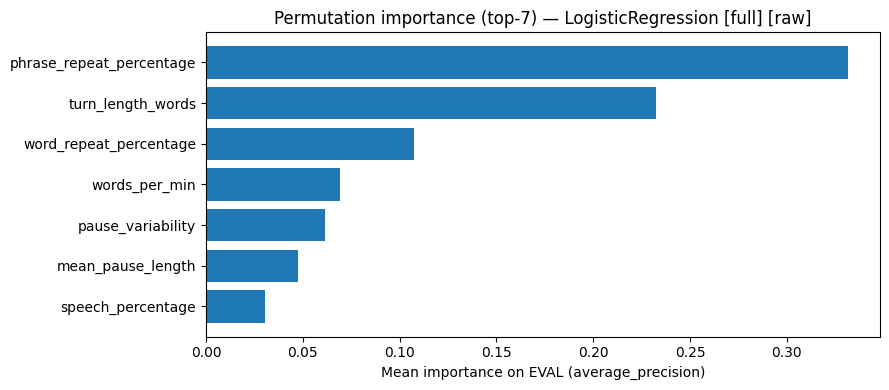


=== LogisticRegression [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Selected cols: ['phrase_repeat_percentage', 'turn_length_words', 'mean_pause_length', 'word_repeat_percentage']
Train+Dev CV PR AUC: 0.5111613746671979 +/- 0.0840099641570737

Classification report:
               precision    recall  f1-score   support

           0      0.833     0.571     0.678        35
           1      0.531     0.810     0.642        21

    accuracy                          0.661        56
   macro avg      0.682     0.690     0.660        56
weighted avg      0.720     0.661     0.664        56

Confusion matrix:
 [[20 15]
 [ 4 17]]

[LogisticRegression [selected(top=5,corr<0.9)]] Top-4 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.276610        0.030159
       turn_length_words         0.227426        0.068580
  

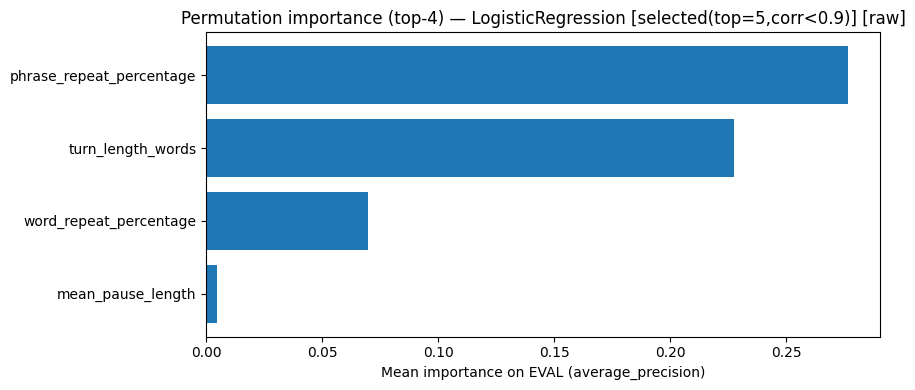


=== SVM [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Best CV score: 0.502 Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.5019948982277745 +/- 0.0681130940104891

Classification report:
               precision    recall  f1-score   support

           0      0.875     0.600     0.712        35
           1      0.562     0.857     0.679        21

    accuracy                          0.696        56
   macro avg      0.719     0.729     0.696        56
weighted avg      0.758     0.696     0.700        56

Confusion matrix:
 [[21 14]
 [ 3 18]]

[SVM [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.315448        0.029160
       turn_length_words         0.220017        0.075195
  word_repeat_percentage         0.086518        0.070543
           words_p

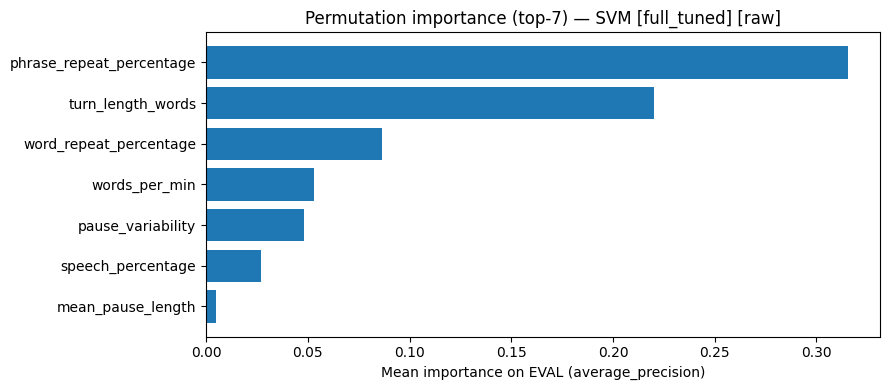


=== SVM [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Selected cols: ['turn_length_words', 'phrase_repeat_percentage', 'pause_variability', 'word_repeat_percentage']
Best CV score: 0.4967 Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.49669698871931267 +/- 0.07944808960703381

Classification report:
               precision    recall  f1-score   support

           0      0.846     0.629     0.721        35
           1      0.567     0.810     0.667        21

    accuracy                          0.696        56
   macro avg      0.706     0.719     0.694        56
weighted avg      0.741     0.696     0.701        56

Confusion matrix:
 [[22 13]
 [ 4 17]]

[SVM [selected_tuned]] Top-4 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.267984        0.027291
       tur

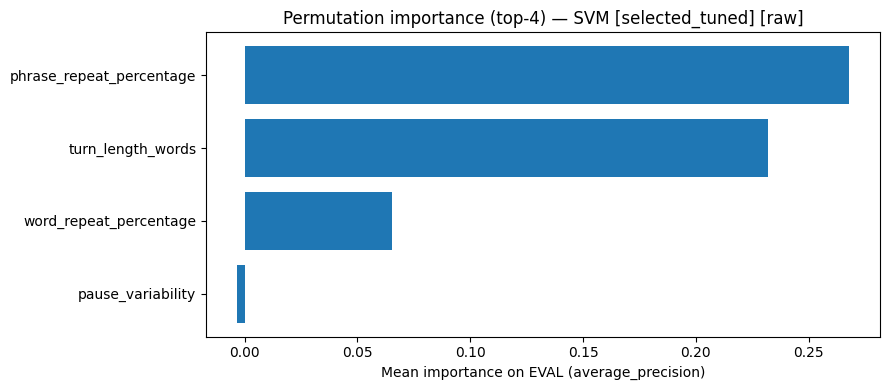


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Train+Dev CV PR AUC: 0.44890663465158714 +/- 0.12550891749328458

Classification report:
               precision    recall  f1-score   support

           0      0.810     0.486     0.607        35
           1      0.486     0.810     0.607        21

    accuracy                          0.607        56
   macro avg      0.648     0.648     0.607        56
weighted avg      0.688     0.607     0.607        56

Confusion matrix:
 [[17 18]
 [ 4 17]]

[SGDClassifier(log_loss) [full]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.220526        0.062756
       pause_variability         0.101456        0.054088
       mean_pause_length         0.053122        0.051693
  word_repeat_percentage         0.042692        0.040258
phrase_repeat_percentage  

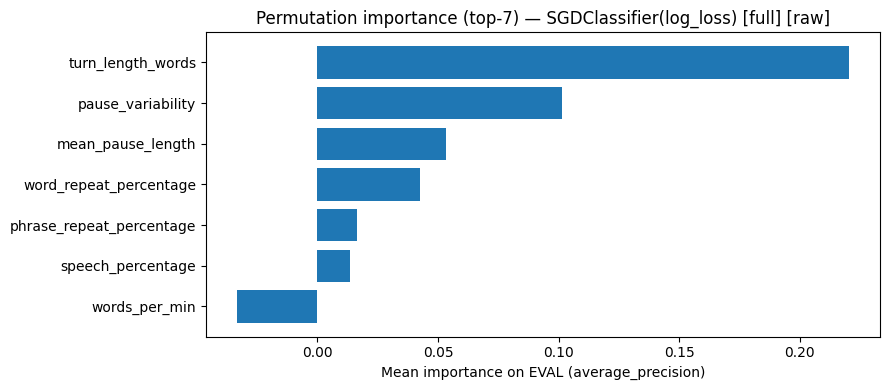


=== SGDClassifier(log_loss) [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Selected cols: ['mean_pause_length', 'turn_length_words', 'phrase_repeat_percentage', 'words_per_min']
Train+Dev CV PR AUC: 0.35406873552627405 +/- 0.0911766711293487

Classification report:
               precision    recall  f1-score   support

           0      0.633     0.543     0.585        35
           1      0.385     0.476     0.426        21

    accuracy                          0.518        56
   macro avg      0.509     0.510     0.505        56
weighted avg      0.540     0.518     0.525        56

Confusion matrix:
 [[19 16]
 [11 10]]

[SGDClassifier(log_loss) [selected(top=5,corr<0.9)]] Top-4 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.121155        0.020196
           words_per_min        -0.044318        0.015545


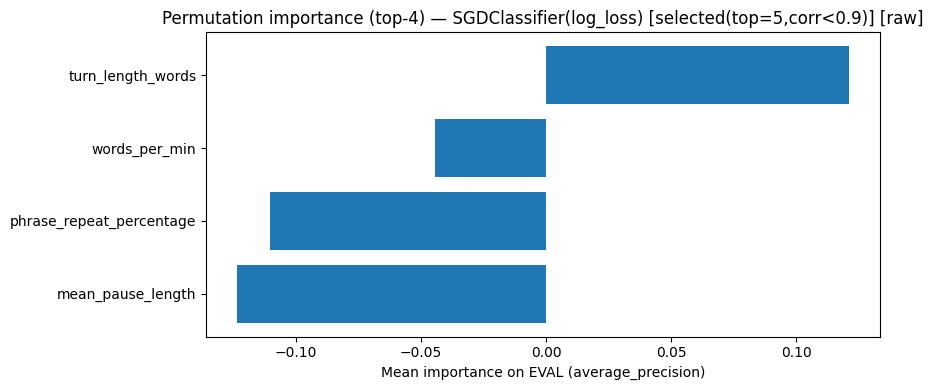


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Best CV score: 0.3452 Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10}
Train+Dev CV PR AUC: 0.34524890157248445 +/- 0.04684844218483205

Classification report:
               precision    recall  f1-score   support

           0      0.606     0.571     0.588        35
           1      0.348     0.381     0.364        21

    accuracy                          0.500        56
   macro avg      0.477     0.476     0.476        56
weighted avg      0.509     0.500     0.504        56

Confusion matrix:
 [[20 15]
 [13  8]]

[DecisionTree [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.040878        0.040252
       pause_variability         0.004391        0.041061
       speech_percentage         0.00

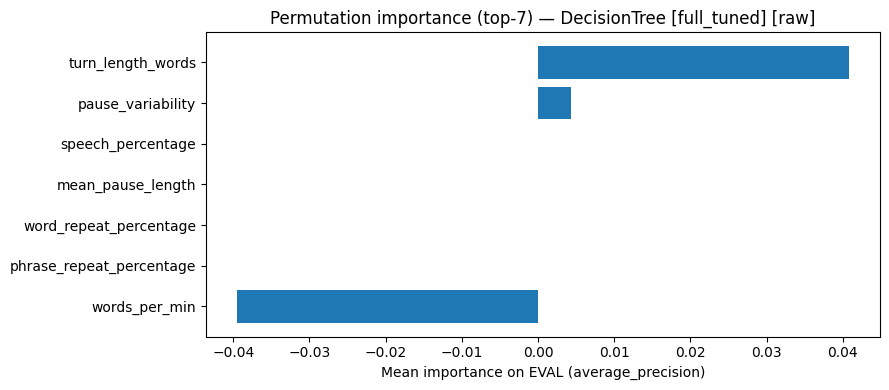


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Selected cols: ['speech_percentage', 'turn_length_words', 'words_per_min', 'pause_variability']
Best CV score: 0.4203 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.42031113780058593 +/- 0.040810240501236716

Classification report:
               precision    recall  f1-score   support

           0      0.640     0.457     0.533        35
           1      0.387     0.571     0.462        21

    accuracy                          0.500        56
   macro avg      0.514     0.514     0.497        56
weighted avg      0.545     0.500     0.506        56

Confusion matrix:
 [[16 19]
 [ 9 12]]

[DecisionTree [selected_tuned]] Top-4 permutation importances (average_precision, raw):
          feature  importance_mean  importance_std
turn_length_words         0.013408        0.026482
pause

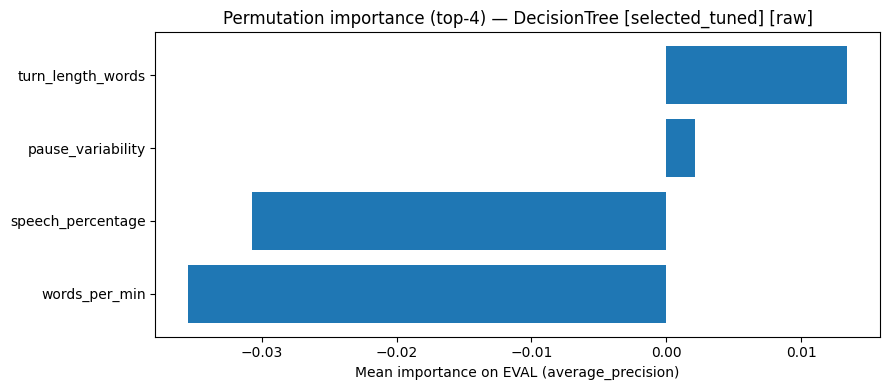


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Best CV score: 0.3913 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.3913264347524938 +/- 0.054777007372571365

Classification report:
               precision    recall  f1-score   support

           0      0.781     0.714     0.746        35
           1      0.583     0.667     0.622        21

    accuracy                          0.696        56
   macro avg      0.682     0.690     0.684        56
weighted avg      0.707     0.696     0.700        56

Confusion matrix:
 [[25 10]
 [ 7 14]]

[RandomForest [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.081535        0.055720
phrase_repeat_percen

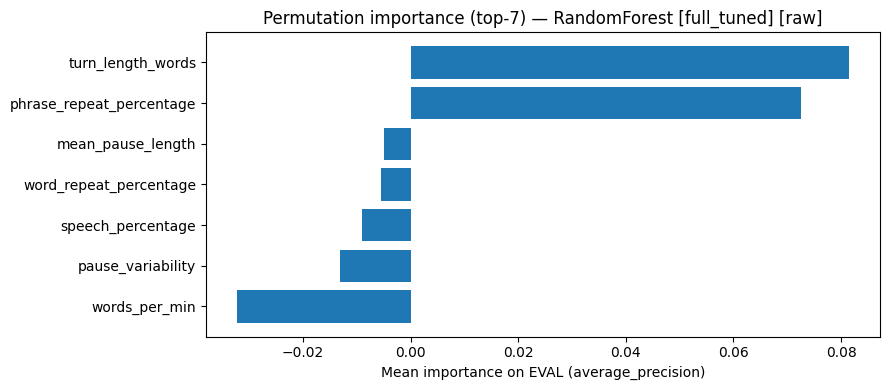


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Selected cols: ['speech_percentage', 'turn_length_words', 'words_per_min', 'pause_variability', 'phrase_repeat_percentage']
Best CV score: 0.4034 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.4034432175264772 +/- 0.03760676098631336

Classification report:
               precision    recall  f1-score   support

           0      0.774     0.686     0.727        35
           1      0.560     0.667     0.609        21

    accuracy                          0.679        56
   macro avg      0.667     0.676     0.668        56
weighted avg      0.694     0.679     0.683        56

Confusion matrix:
 [[24 11]
 [ 7 14]]

[RandomForest [selected_tuned]] Top-5 permutation importances (average_precision, raw):
 

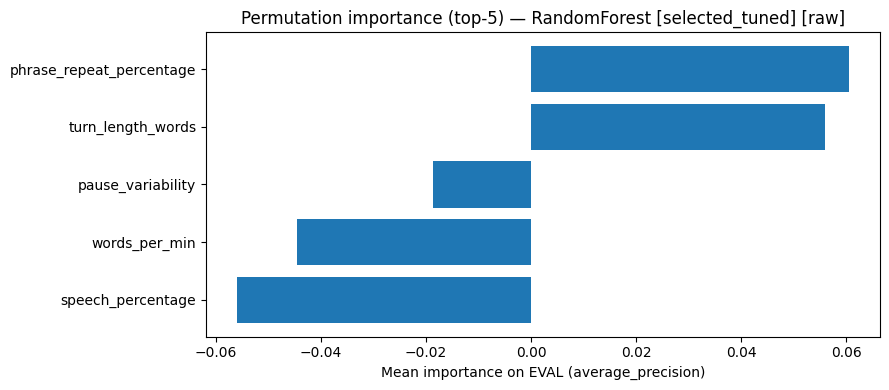


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Best CV score: 0.4069 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 1.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.4069300484669004 +/- 0.0455285722254316

Classification report:
               precision    recall  f1-score   support

           0      0.680     0.486     0.567        35
           1      0.419     0.619     0.500        21

    accuracy                          0.536        56
   macro avg      0.550     0.552     0.533        56
weighted avg      0.582     0.536     0.542        56

Confusion matrix:
 [[17 18]
 [ 8 13]]

[XGBoost [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.083070        0.032648
      

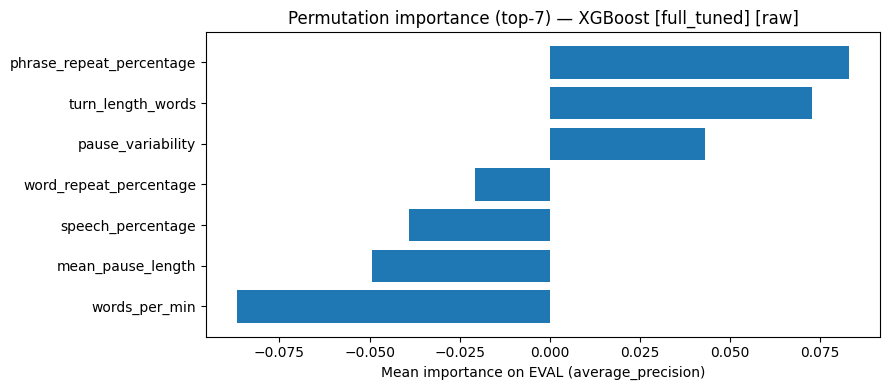


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Selected cols: ['turn_length_words', 'words_per_min', 'speech_percentage', 'phrase_repeat_percentage', 'pause_variability']
Best CV score: 0.4445 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 1.0}
Train+Dev CV PR AUC: 0.4445384702580137 +/- 0.06024936827144162

Classification report:
               precision    recall  f1-score   support

           0      0.741     0.571     0.645        35
           1      0.483     0.667     0.560        21

    accuracy                          0.607        56
   macro avg      0.612     0.619     0.603        56
weighted avg      0.644     0.607     0.613        56

Confusion matrix:
 [[20 15]
 [ 7 14]]

[XGBoost [selected_tuned]] Top-5 permutation importances (average_precis

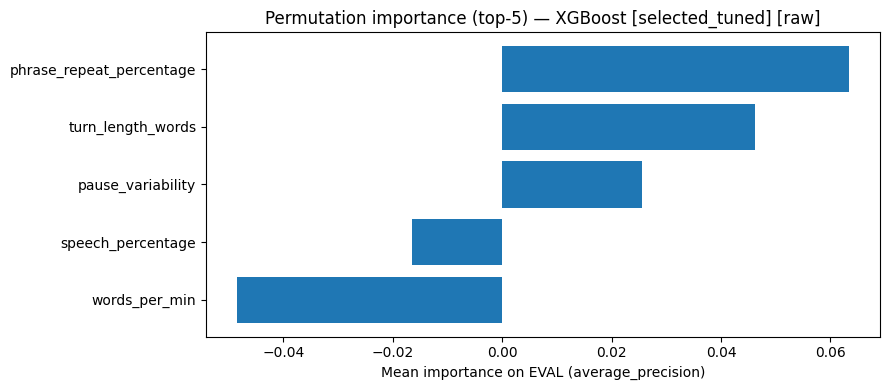


=== Summary metrics on TEST (tuned by PR AUC) ===
    target                   model                  variant  tuned  cv_best_score  cv_pr_auc_mean  cv_pr_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                selected_cols
PTSD_label      LogisticRegression                     full  False            NaN          0.4926         0.0758                                                                                                                                                                                           219      56               7                  NaN    0.6964    0.6956 0.5828 0.8020        0.7286   0.7796  0.6435  0.9034

In [4]:
res_b0_ptsd = run_models_pipeline_more_models_tuned_prauc(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_{LANGUAGE}_small_test{ITERATION}.csv",
    target_col="PTSD_label",
    importance_top_k=5,
)


In [5]:
res_b0_ptsd

,target,model,variant,tuned,cv_best_score,cv_pr_auc_mean,cv_pr_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,PTSD_label,LogisticRegression,full,False,NaN,0.492617,0.075843,,219,56,...,0.695555,0.582766,0.801993,0.728571,0.779592,0.643503,0.903401,0.708995,0.211994,
1,PTSD_label,LogisticRegression,"selected(top=5,corr<0.9)",False,NaN,0.511161,0.084010,,219,56,...,0.659738,0.535714,0.781299,0.690476,0.738776,0.595884,0.874830,0.642610,0.218955,"phrase_repeat_percentage,turn_length_words,mea..."
2,PTSD_label,SVM,full_tuned,True,0.501995,0.501995,0.068113,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",219,56,...,0.695555,0.571429,0.803006,0.728571,0.760544,0.616327,0.891190,0.682455,0.207007,
3,PTSD_label,SVM,selected_tuned,True,0.496697,0.496697,0.079448,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke...",219,56,...,0.693989,0.582766,0.801993,0.719048,0.719728,0.574116,0.855816,0.626022,0.215899,"turn_length_words,phrase_repeat_percentage,pau..."
4,PTSD_label,SGDClassifier(log_loss),full,False,NaN,0.448907,0.125509,,219,56,...,0.607143,0.480652,0.729990,0.647619,0.689796,0.540102,0.829932,0.607268,0.374802,
5,PTSD_label,SGDClassifier(log_loss),"selected(top=5,corr<0.9)",False,NaN,0.354069,0.091177,,219,56,...,0.505074,0.373201,0.631094,0.509524,0.530612,0.375510,0.683027,0.414430,0.372609,"mean_pause_length,turn_length_words,phrase_rep..."
6,PTSD_label,DecisionTree,full_tuned,True,0.345249,0.345249,0.046848,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",219,56,...,0.475936,0.338889,0.603677,0.476190,0.542177,0.390459,0.678248,0.441450,0.283715,
7,PTSD_label,DecisionTree,selected_tuned,True,0.420311,0.420311,0.040810,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.497436,0.369977,0.621986,0.514286,0.526531,0.377466,0.676871,0.396070,0.304515,"speech_percentage,turn_length_words,words_per_..."
8,PTSD_label,RandomForest,full_tuned,True,0.391326,0.391326,0.054777,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.684245,0.550802,0.798363,0.690476,0.700680,0.548231,0.842211,0.566112,0.220266,
9,PTSD_label,RandomForest,selected_tuned,True,0.403443,0.403443,0.037607,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.667984,0.535655,0.792383,0.676190,0.661224,0.507449,0.805442,0.512800,0.229203,"speech_percentage,turn_length_words,words_per_..."



[INFO] target_col = PTSD_label
[INFO] standardized drop_cols (8): ['Depression_label', 'Depression_severity', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 13) | X_test shape: (56, 13)
[INFO] class counts train: [153  66] | test: [35 21]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Train+Dev CV PR AUC: 0.4566432046470418 +/- 0.0785399916749694

Classification report:
               precision    recall  f1-score   support

           0      0.750     0.771     0.761        35
           1      0.600     0.571     0.585        21

    accuracy                          0.696        56
   macro avg      0.675     0.671     0.673        56
weighted avg      0.694     0.696     0.695        56

Confusion matrix:
 [[27  8]
 [ 9 12]]

[LogisticRegression [full]] Top-10 permutation importances (average_precision, raw):
                               feat

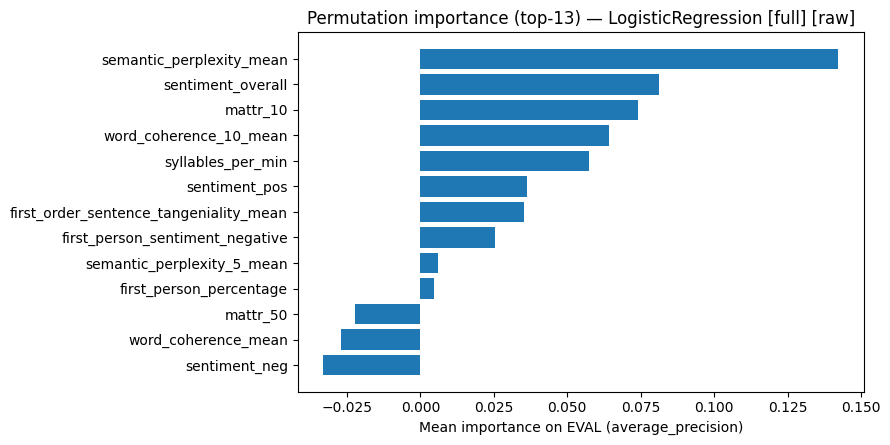


=== LogisticRegression [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Selected cols: ['word_coherence_10_mean', 'semantic_perplexity_mean', 'mattr_10', 'sentiment_overall']
Train+Dev CV PR AUC: 0.4566778538502113 +/- 0.034683968943581826

Classification report:
               precision    recall  f1-score   support

           0      0.692     0.514     0.590        35
           1      0.433     0.619     0.510        21

    accuracy                          0.554        56
   macro avg      0.563     0.567     0.550        56
weighted avg      0.595     0.554     0.560        56

Confusion matrix:
 [[18 17]
 [ 8 13]]

[LogisticRegression [selected(top=5,corr<0.9)]] Top-4 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
semantic_perplexity_mean         0.134150        0.018509
  word_coherence_10_mean         0.080524        0.039436
          

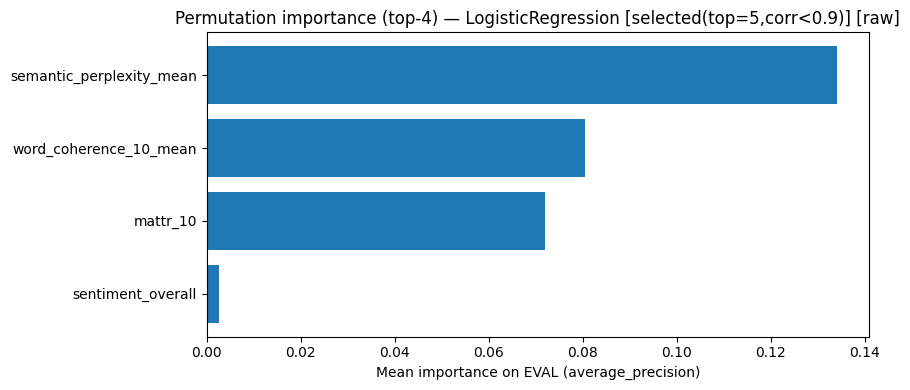


=== SVM [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Best CV score: 0.4573 Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.45731277591009506 +/- 0.08276990822470362

Classification report:
               precision    recall  f1-score   support

           0      0.750     0.686     0.716        35
           1      0.542     0.619     0.578        21

    accuracy                          0.661        56
   macro avg      0.646     0.652     0.647        56
weighted avg      0.672     0.661     0.664        56

Confusion matrix:
 [[24 11]
 [ 8 13]]

[SVM [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
              semantic_perplexity_mean         0.125988        0.025146
                              mattr_10         0.065965        0.019448
                     syllables_

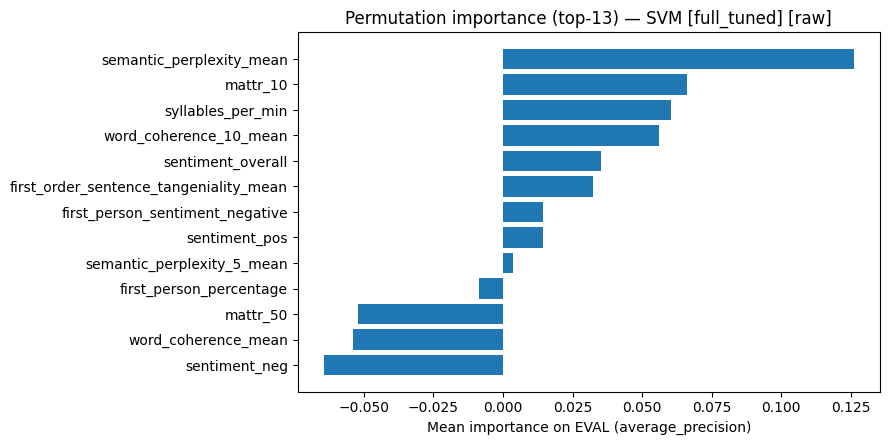


=== SVM [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Selected cols: ['first_person_percentage', 'sentiment_pos', 'word_coherence_10_mean']
Best CV score: 0.4273 Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.4272541392894892 +/- 0.033485397982182516

Classification report:
               precision    recall  f1-score   support

           0      0.800     0.457     0.582        35
           1      0.472     0.810     0.596        21

    accuracy                          0.589        56
   macro avg      0.636     0.633     0.589        56
weighted avg      0.677     0.589     0.587        56

Confusion matrix:
 [[16 19]
 [ 4 17]]

[SVM [selected_tuned]] Top-3 permutation importances (average_precision, raw):
                feature  importance_mean  importance_std
          sentiment_pos         0.004827        0.015366
first_person_percentage        -0.0023

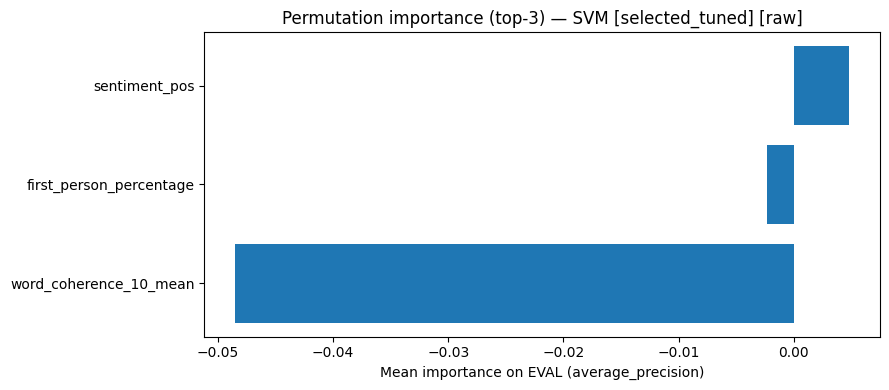


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Train+Dev CV PR AUC: 0.37907289753323503 +/- 0.0717153555818692

Classification report:
               precision    recall  f1-score   support

           0      0.683     0.800     0.737        35
           1      0.533     0.381     0.444        21

    accuracy                          0.643        56
   macro avg      0.608     0.590     0.591        56
weighted avg      0.627     0.643     0.627        56

Confusion matrix:
 [[28  7]
 [13  8]]

[SGDClassifier(log_loss) [full]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
first_order_sentence_tangeniality_mean         0.096647        0.031617
                word_coherence_10_mean         0.075692        0.041465
       first_person_sentiment_negative         0.072061        0.044089
              semantic_perple

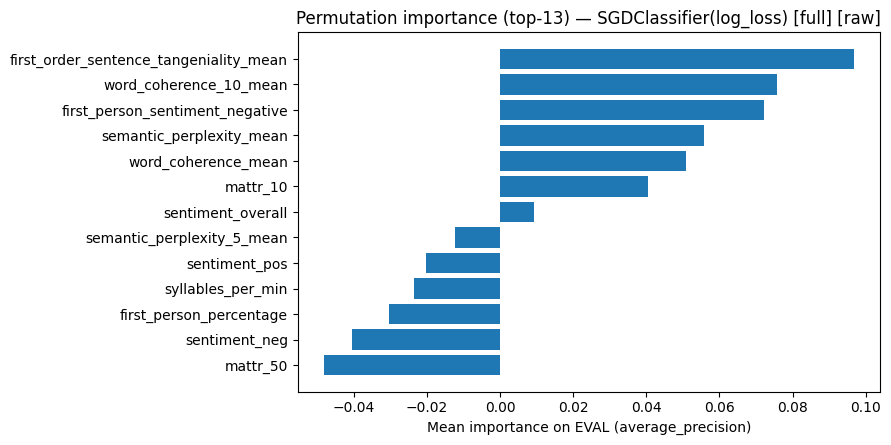


=== SGDClassifier(log_loss) [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Selected cols: ['word_coherence_10_mean', 'mattr_10', 'sentiment_pos', 'semantic_perplexity_mean']
Train+Dev CV PR AUC: 0.387368634375815 +/- 0.060959954321415766

Classification report:
               precision    recall  f1-score   support

           0      0.640     0.914     0.753        35
           1      0.500     0.143     0.222        21

    accuracy                          0.625        56
   macro avg      0.570     0.529     0.488        56
weighted avg      0.588     0.625     0.554        56

Confusion matrix:
 [[32  3]
 [18  3]]

[SGDClassifier(log_loss) [selected(top=5,corr<0.9)]] Top-4 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
                mattr_10         0.048071        0.025105
semantic_perplexity_mean         0.032731        0.046267
  wor

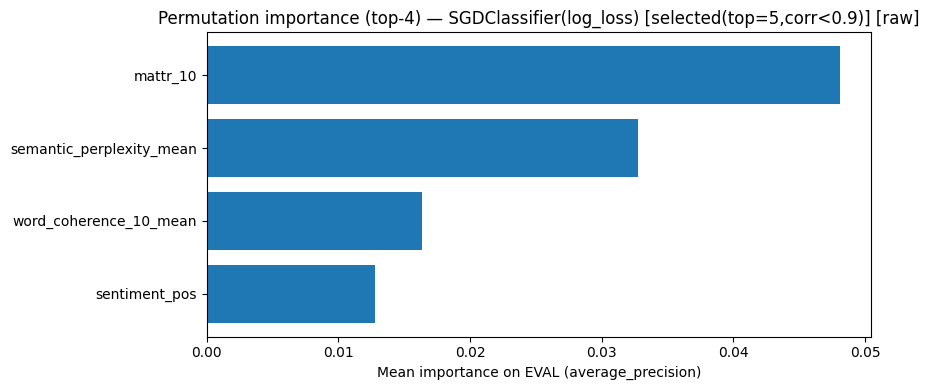

[WARN] DecisionTree[full]: very few unique predicted probabilities (4).

=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Best CV score: 0.3313 Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10}
Train+Dev CV PR AUC: 0.3312948532731678 +/- 0.011292094984853056

Classification report:
               precision    recall  f1-score   support

           0      0.333     0.029     0.053        35
           1      0.358     0.905     0.514        21

    accuracy                          0.357        56
   macro avg      0.346     0.467     0.283        56
weighted avg      0.343     0.357     0.225        56

Confusion matrix:
 [[ 1 34]
 [ 2 19]]

[DecisionTree [full_tuned]] Top-10 permutation importances (average_precision, raw):
                        feature  importance_mean  importance_std
     semantic_perplexity_5_mean         0.059119        0.009524
first_per

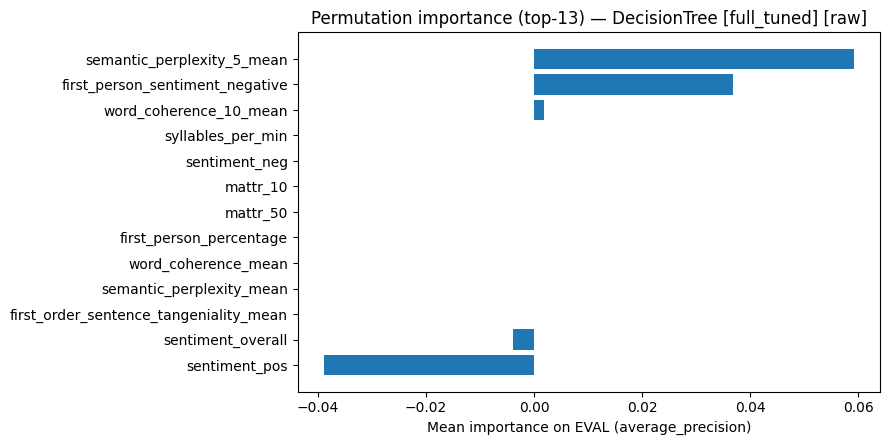


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Selected cols: ['sentiment_pos', 'mattr_10', 'word_coherence_mean', 'semantic_perplexity_mean', 'first_person_percentage']
Best CV score: 0.3512 Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10}
Train+Dev CV PR AUC: 0.3511556283867573 +/- 0.036491004381877794

Classification report:
               precision    recall  f1-score   support

           0      0.676     0.657     0.667        35
           1      0.455     0.476     0.465        21

    accuracy                          0.589        56
   macro avg      0.566     0.567     0.566        56
weighted avg      0.593     0.589     0.591        56

Confusion matrix:
 [[23 12]
 [11 10]]

[DecisionTree [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
semantic_perplexity_me

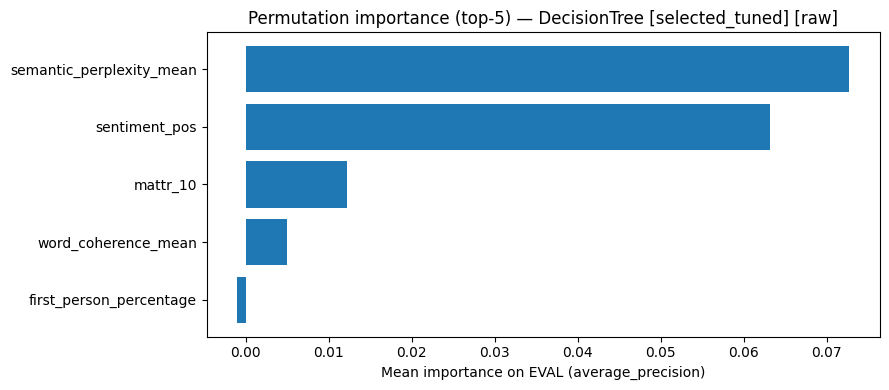


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Best CV score: 0.4184 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 500}
Train+Dev CV PR AUC: 0.4183980499081679 +/- 0.13925343742078963

Classification report:
               precision    recall  f1-score   support

           0      0.694     0.714     0.704        35
           1      0.500     0.476     0.488        21

    accuracy                          0.625        56
   macro avg      0.597     0.595     0.596        56
weighted avg      0.622     0.625     0.623        56

Confusion matrix:
 [[25 10]
 [11 10]]

[RandomForest [full_tuned]] Top-10 permutation importances (average_precision, raw):
                        feature  importance_mean  importance_std
              syllables_per_min         0.048236        0.026186
   

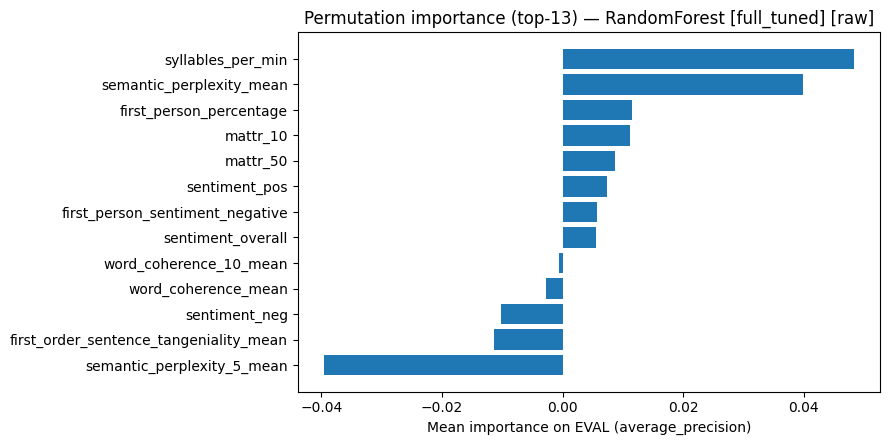


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Selected cols: ['word_coherence_10_mean', 'sentiment_pos', 'mattr_10']
Best CV score: 0.4743 Best params: {'clf__bootstrap': True, 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 500}
Train+Dev CV PR AUC: 0.4743101321130946 +/- 0.055809556345517965

Classification report:
               precision    recall  f1-score   support

           0      0.700     0.800     0.747        35
           1      0.562     0.429     0.486        21

    accuracy                          0.661        56
   macro avg      0.631     0.614     0.617        56
weighted avg      0.648     0.661     0.649        56

Confusion matrix:
 [[28  7]
 [12  9]]

[RandomForest [selected_tuned]] Top-3 permutation importances (average_precision, raw):
               feature  importance_mean  importance_st

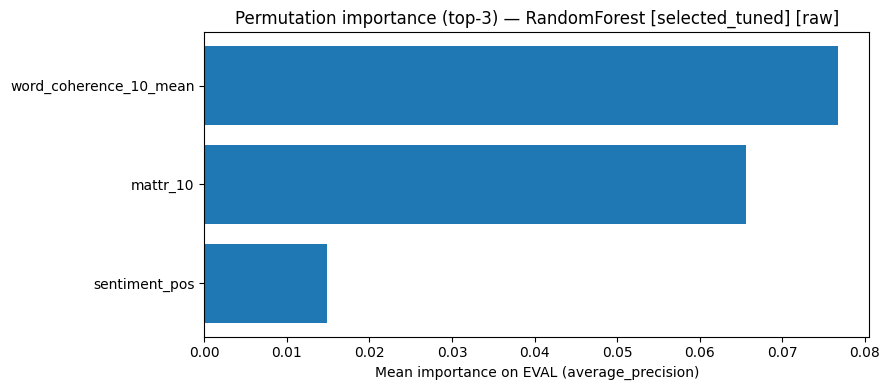


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Best CV score: 0.4016 Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__min_child_weight': 5, 'clf__n_estimators': 500, 'clf__reg_lambda': 1.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.4016449778195989 +/- 0.09245618413960029

Classification report:
               precision    recall  f1-score   support

           0      0.694     0.714     0.704        35
           1      0.500     0.476     0.488        21

    accuracy                          0.625        56
   macro avg      0.597     0.595     0.596        56
weighted avg      0.622     0.625     0.623        56

Confusion matrix:
 [[25 10]
 [11 10]]

[XGBoost [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                     syllables_per_min         0.0

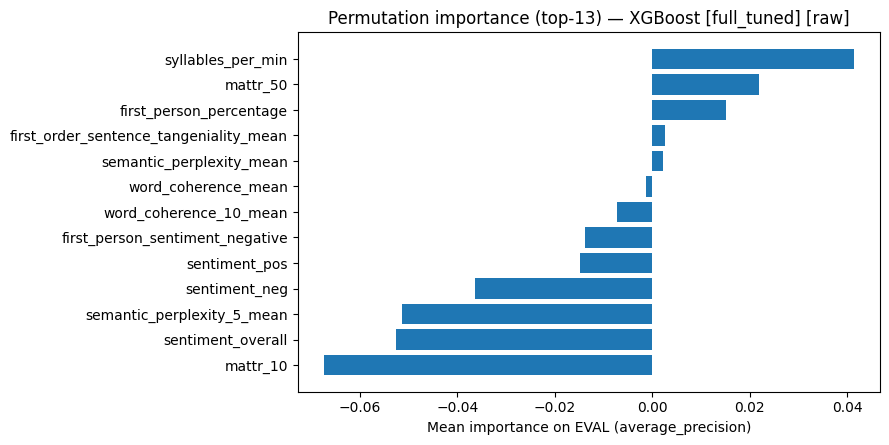


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Selected cols: ['word_coherence_mean', 'sentiment_overall', 'sentiment_pos', 'mattr_10']
Best CV score: 0.4391 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 1.0}
Train+Dev CV PR AUC: 0.43907053582738625 +/- 0.08017120707958181

Classification report:
               precision    recall  f1-score   support

           0      0.667     0.629     0.647        35
           1      0.435     0.476     0.455        21

    accuracy                          0.571        56
   macro avg      0.551     0.552     0.551        56
weighted avg      0.580     0.571     0.575        56

Confusion matrix:
 [[22 13]
 [11 10]]

[XGBoost [selected_tuned]] Top-4 permutation importances (average_precision, raw):
            feature  imp

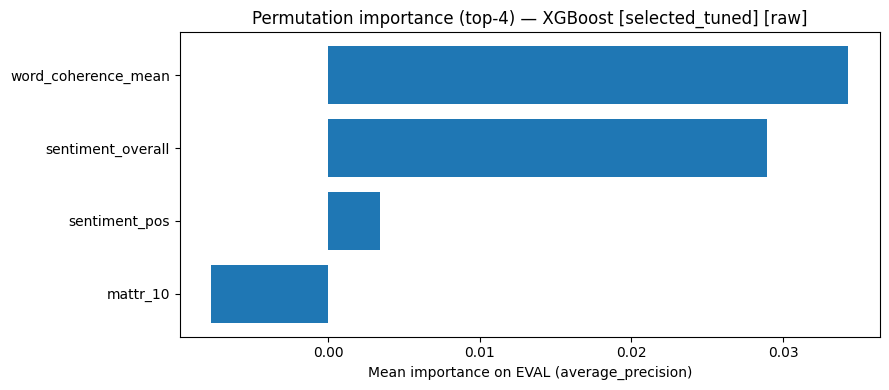


=== Summary metrics on TEST (tuned by PR AUC) ===
    target                   model                  variant  tuned  cv_best_score  cv_pr_auc_mean  cv_pr_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                               selected_cols
PTSD_label      LogisticRegression                     full  False            NaN          0.4566         0.0785                                                                                                                                                                                           219      56              13                  NaN    0.6964    0.6730 0.5359 0.7924        0.6714   0.6952  0.5401  0.8300 

In [6]:
res_l_ptsd = run_models_pipeline_more_models_tuned_prauc(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_{LANGUAGE}_small_test{ITERATION}.csv",
    target_col="PTSD_label",
    importance_top_k=5,
)

In [7]:
res_l_ptsd

,target,model,variant,tuned,cv_best_score,cv_pr_auc_mean,cv_pr_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,PTSD_label,LogisticRegression,full,False,NaN,0.456643,0.078540,,219,56,...,0.672965,0.535851,0.792383,0.671429,0.695238,0.540136,0.829966,0.567652,0.220418,
1,PTSD_label,LogisticRegression,"selected(top=5,corr<0.9)",False,NaN,0.456678,0.034684,,219,56,...,0.549984,0.410526,0.678571,0.566667,0.617687,0.453027,0.766054,0.537631,0.251680,"word_coherence_10_mean,semantic_perplexity_mea..."
2,PTSD_label,SVM,full_tuned,True,0.457313,0.457313,0.082770,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",219,56,...,0.647098,0.510204,0.766786,0.652381,0.687075,0.527857,0.824490,0.539757,0.232311,
3,PTSD_label,SVM,selected_tuned,True,0.427254,0.427254,0.033485,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k...",219,56,...,0.589155,0.458065,0.712821,0.633333,0.590476,0.435374,0.732041,0.414675,0.235997,"first_person_percentage,sentiment_pos,word_coh..."
4,PTSD_label,SGDClassifier(log_loss),full,False,NaN,0.379073,0.071715,,219,56,...,0.590643,0.453659,0.721195,0.590476,0.553741,0.371395,0.717007,0.505405,0.319915,
5,PTSD_label,SGDClassifier(log_loss),"selected(top=5,corr<0.9)",False,NaN,0.387369,0.060960,,219,56,...,0.487582,0.370787,0.620868,0.528571,0.517007,0.349626,0.676190,0.468179,0.333519,"word_coherence_10_mean,mattr_10,sentiment_pos,..."
6,PTSD_label,DecisionTree,full_tuned,True,0.331295,0.331295,0.011292,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",219,56,...,0.283073,0.232877,0.352381,0.466667,0.536054,0.428571,0.642857,0.451707,0.259735,
7,PTSD_label,DecisionTree,selected_tuned,True,0.351156,0.351156,0.036491,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",219,56,...,0.565891,0.428571,0.695238,0.566667,0.597279,0.435969,0.748316,0.509660,0.306328,"sentiment_pos,mattr_10,word_coherence_mean,sem..."
8,PTSD_label,RandomForest,full_tuned,True,0.418398,0.418398,0.139253,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.596015,0.455135,0.721393,0.595238,0.623129,0.450340,0.778265,0.564023,0.232017,
9,PTSD_label,RandomForest,selected_tuned,True,0.474310,0.474310,0.055810,"{'clf__bootstrap': True, 'clf__max_depth': 10,...",219,56,...,0.616577,0.467836,0.744292,0.614286,0.536054,0.356429,0.702041,0.483267,0.253287,"word_coherence_10_mean,sentiment_pos,mattr_10"



[INFO] target_col = PTSD_label
[INFO] standardized drop_cols (8): ['Depression_label', 'Depression_severity', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 20) | X_test shape: (56, 20)
[INFO] class counts train: [153  66] | test: [35 21]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Train+Dev CV PR AUC: 0.5219195919864863 +/- 0.11337825340860797

Classification report:
               precision    recall  f1-score   support

           0      0.758     0.714     0.735        35
           1      0.565     0.619     0.591        21

    accuracy                          0.679        56
   macro avg      0.661     0.667     0.663        56
weighted avg      0.685     0.679     0.681        56

Confusion matrix:
 [[25 10]
 [ 8 13]]

[LogisticRegression [full]] Top-10 permutation importances (average_precision, raw):
                               f

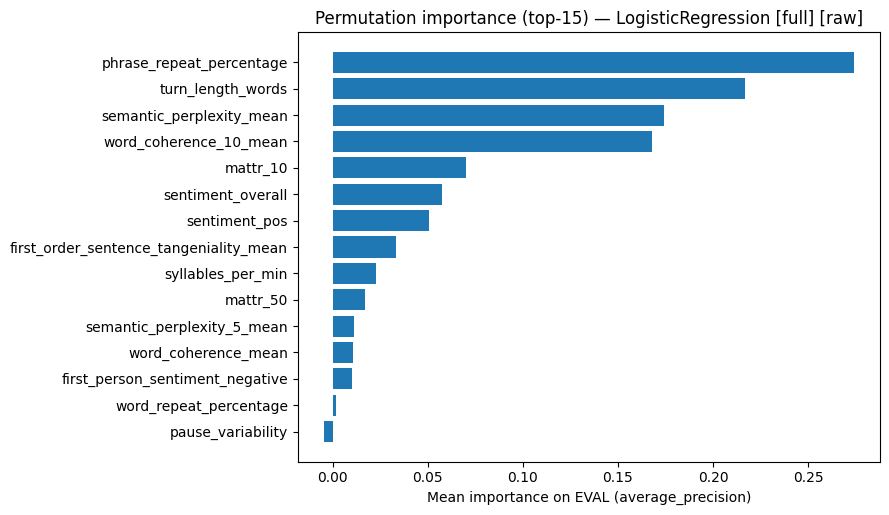


=== LogisticRegression [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Selected cols: ['word_coherence_10_mean', 'phrase_repeat_percentage', 'semantic_perplexity_mean', 'turn_length_words']
Train+Dev CV PR AUC: 0.5149514573687874 +/- 0.10955248926080167

Classification report:
               precision    recall  f1-score   support

           0      0.840     0.600     0.700        35
           1      0.548     0.810     0.654        21

    accuracy                          0.679        56
   macro avg      0.694     0.705     0.677        56
weighted avg      0.731     0.679     0.683        56

Confusion matrix:
 [[21 14]
 [ 4 17]]

[LogisticRegression [selected(top=5,corr<0.9)]] Top-4 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
  word_coherence_10_mean         0.193629        0.054267
       turn_length_words         0.151322        0.

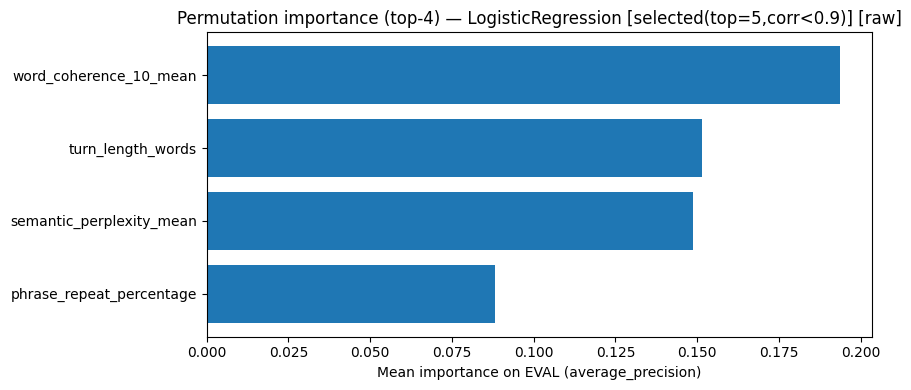


=== SVM [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Best CV score: 0.5642 Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.5641794443489705 +/- 0.12296607229919398

Classification report:
               precision    recall  f1-score   support

           0      0.719     0.657     0.687        35
           1      0.500     0.571     0.533        21

    accuracy                          0.625        56
   macro avg      0.609     0.614     0.610        56
weighted avg      0.637     0.625     0.629        56

Confusion matrix:
 [[23 12]
 [ 9 12]]

[SVM [full_tuned]] Top-10 permutation importances (average_precision, raw):
                   feature  importance_mean  importance_std
  phrase_repeat_percentage         0.301138        0.028692
         turn_length_words         0.243131        0.048494
    word_coherence_10_mean         0.165602        0.047433
  sema

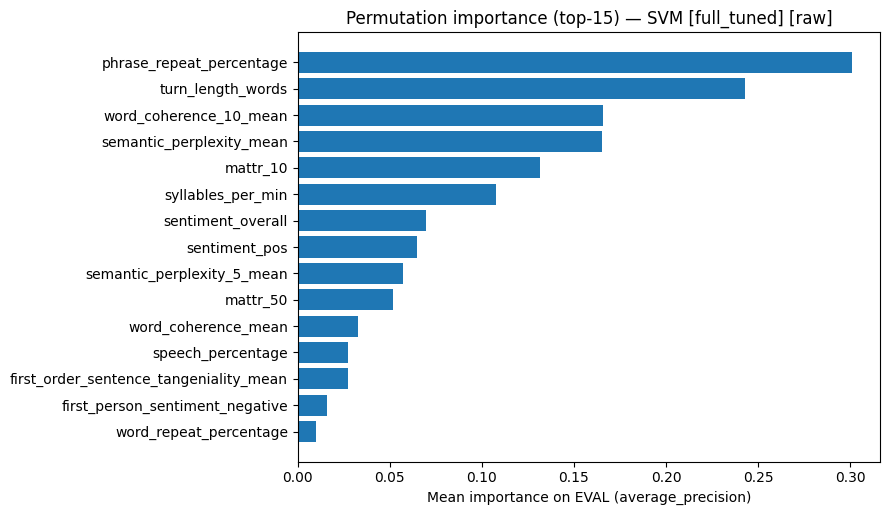


=== SVM [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Selected cols: ['turn_length_words', 'words_per_min', 'semantic_perplexity_mean', 'sentiment_pos', 'phrase_repeat_percentage']
Best CV score: 0.486 Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.4859906095503848 +/- 0.13613081751999723

Classification report:
               precision    recall  f1-score   support

           0      0.828     0.686     0.750        35
           1      0.593     0.762     0.667        21

    accuracy                          0.714        56
   macro avg      0.710     0.724     0.708        56
weighted avg      0.739     0.714     0.719        56

Confusion matrix:
 [[24 11]
 [ 5 16]]

[SVM [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.143709        0.0638

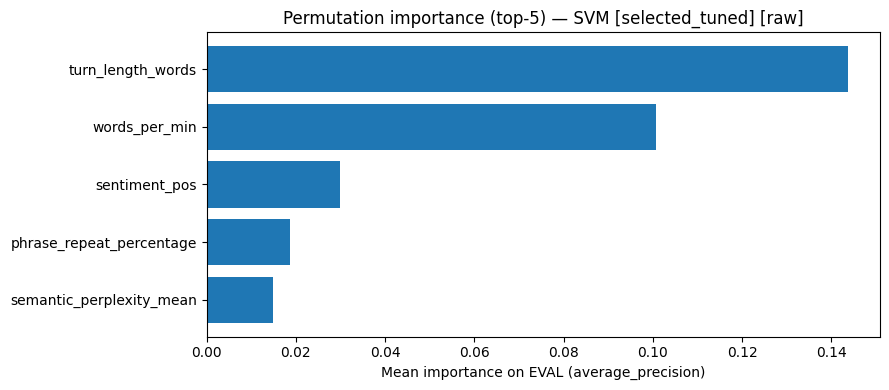


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Train+Dev CV PR AUC: 0.3952032199228764 +/- 0.0819273715364116

Classification report:
               precision    recall  f1-score   support

           0      0.660     0.886     0.756        35
           1      0.556     0.238     0.333        21

    accuracy                          0.643        56
   macro avg      0.608     0.562     0.545        56
weighted avg      0.621     0.643     0.598        56

Confusion matrix:
 [[31  4]
 [16  5]]

[SGDClassifier(log_loss) [full]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                     turn_length_words         0.075923        0.035856
                word_coherence_10_mean         0.075133        0.038790
first_order_sentence_tangeniality_mean         0.053514        0.054453
              semantic_perpl

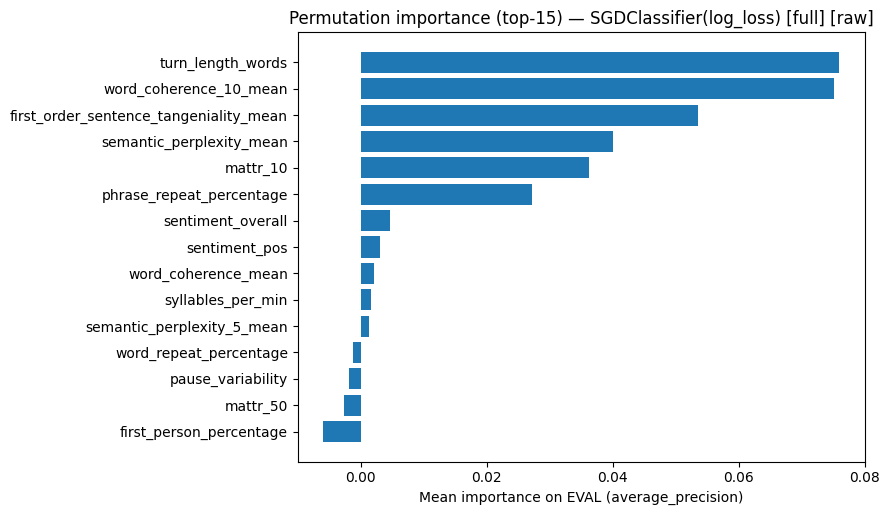


=== SGDClassifier(log_loss) [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Selected cols: ['word_coherence_10_mean', 'mean_pause_length', 'sentiment_overall', 'mattr_10']
Train+Dev CV PR AUC: 0.420552264278579 +/- 0.1100228895319457

Classification report:
               precision    recall  f1-score   support

           0      0.833     0.429     0.566        35
           1      0.474     0.857     0.610        21

    accuracy                          0.589        56
   macro avg      0.654     0.643     0.588        56
weighted avg      0.698     0.589     0.583        56

Confusion matrix:
 [[15 20]
 [ 3 18]]

[SGDClassifier(log_loss) [selected(top=5,corr<0.9)]] Top-4 permutation importances (average_precision, raw):
               feature  importance_mean  importance_std
     mean_pause_length         0.108740        0.050894
     sentiment_overall         0.028165        0.033345
              

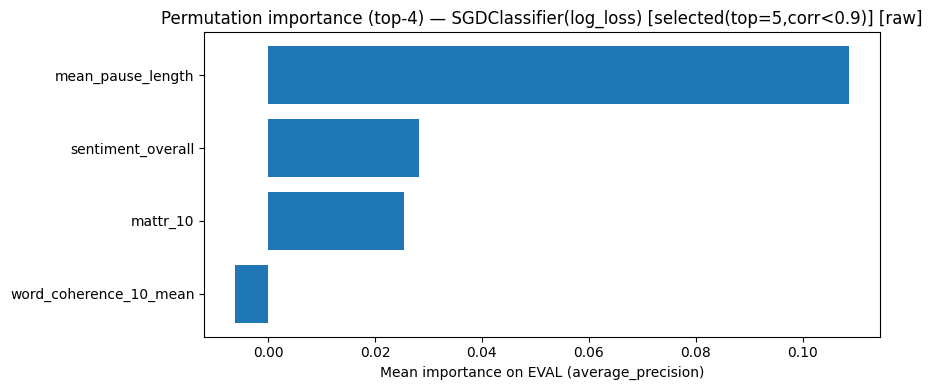


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Best CV score: 0.3959 Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10}
Train+Dev CV PR AUC: 0.3959397203701351 +/- 0.07946937140512489

Classification report:
               precision    recall  f1-score   support

           0      0.667     0.743     0.703        35
           1      0.471     0.381     0.421        21

    accuracy                          0.607        56
   macro avg      0.569     0.562     0.562        56
weighted avg      0.593     0.607     0.597        56

Confusion matrix:
 [[26  9]
 [13  8]]

[DecisionTree [full_tuned]] Top-10 permutation importances (average_precision, raw):
                        feature  importance_mean  importance_std
              turn_length_words         0.069247        0.017219
                       mattr_10         0.019654        0.053540
              

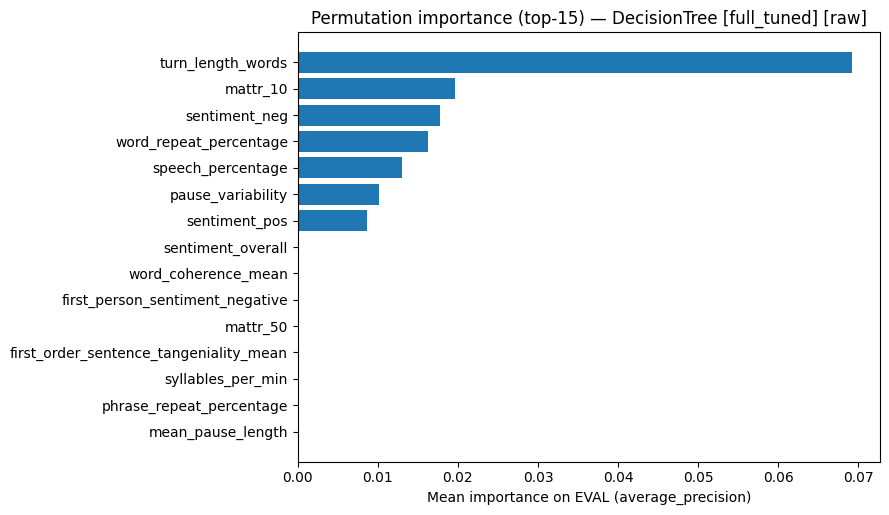


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Selected cols: ['sentiment_pos', 'words_per_min', 'first_person_percentage', 'turn_length_words', 'first_order_sentence_tangeniality_mean']
Best CV score: 0.445 Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.44496980331158015 +/- 0.11233494374571894

Classification report:
               precision    recall  f1-score   support

           0      0.543     0.543     0.543        35
           1      0.238     0.238     0.238        21

    accuracy                          0.429        56
   macro avg      0.390     0.390     0.390        56
weighted avg      0.429     0.429     0.429        56

Confusion matrix:
 [[19 16]
 [16  5]]

[DecisionTree [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                               feature  importance_mean  import

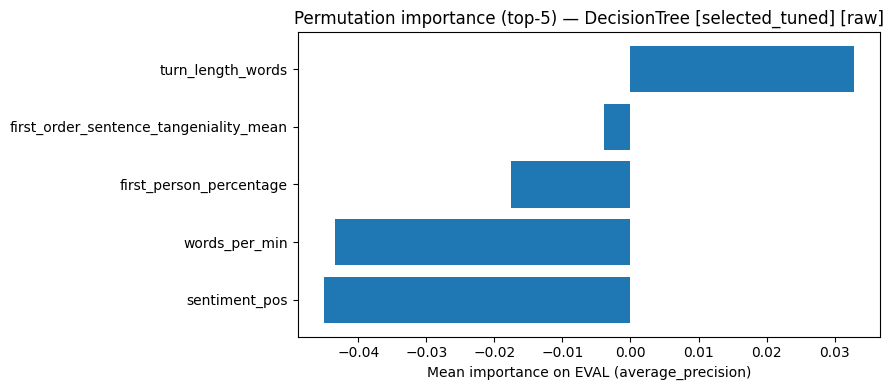


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Best CV score: 0.414 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.4139510473073257 +/- 0.08370210182689007

Classification report:
               precision    recall  f1-score   support

           0      0.698     0.857     0.769        35
           1      0.615     0.381     0.471        21

    accuracy                          0.679        56
   macro avg      0.657     0.619     0.620        56
weighted avg      0.667     0.679     0.657        56

Confusion matrix:
 [[30  5]
 [13  8]]

[RandomForest [full_tuned]] Top-10 permutation importances (average_precision, raw):
                        feature  importance_mean  importance_std
              turn_length_words         0.091682        0.052466
     

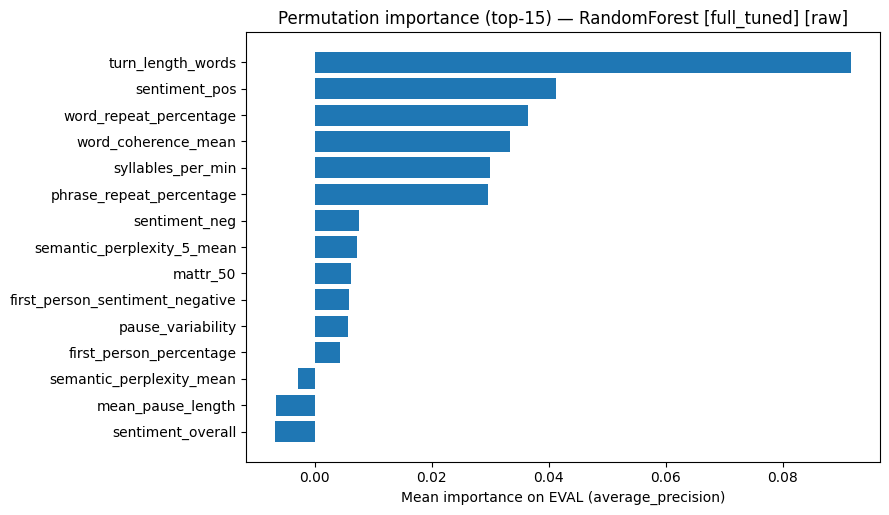


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Selected cols: ['word_coherence_mean', 'words_per_min', 'speech_percentage', 'sentiment_pos']
Best CV score: 0.3906 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.3906449115454561 +/- 0.056977042283351334

Classification report:
               precision    recall  f1-score   support

           0      0.622     0.657     0.639        35
           1      0.368     0.333     0.350        21

    accuracy                          0.536        56
   macro avg      0.495     0.495     0.494        56
weighted avg      0.527     0.536     0.531        56

Confusion matrix:
 [[23 12]
 [14  7]]

[RandomForest [selected_tuned]] Top-4 permutation importances (average_precision, raw):
            feature  importanc

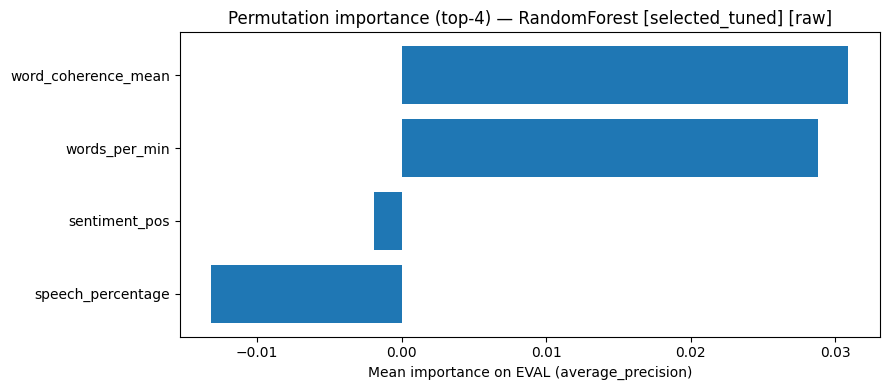


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Best CV score: 0.4018 Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.40183439071279875 +/- 0.09227203075176668

Classification report:
               precision    recall  f1-score   support

           0      0.727     0.686     0.706        35
           1      0.522     0.571     0.545        21

    accuracy                          0.643        56
   macro avg      0.625     0.629     0.626        56
weighted avg      0.650     0.643     0.646        56

Confusion matrix:
 [[24 11]
 [ 9 12]]

[XGBoost [full_tuned]] Top-10 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.087301        0.060403
ph

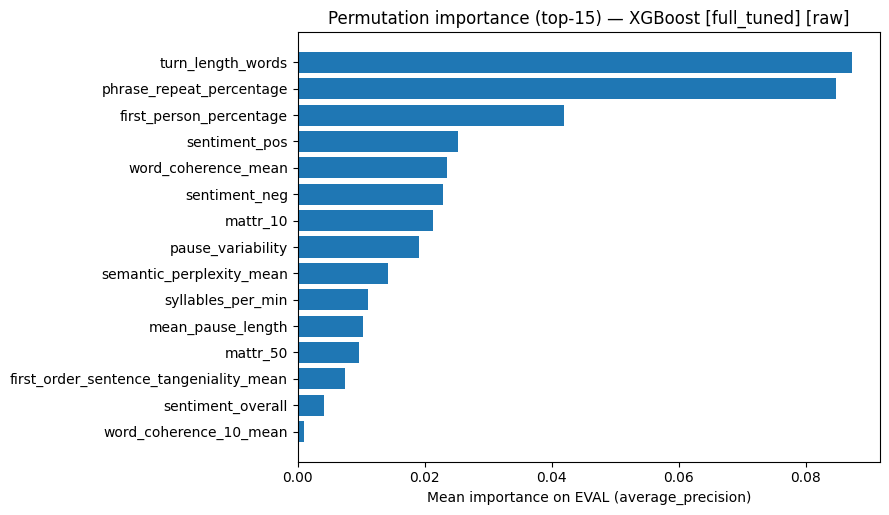


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Selected cols: ['words_per_min', 'pause_variability', 'word_coherence_mean', 'speech_percentage']
Best CV score: 0.4596 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.4596079131200601 +/- 0.0756079624631844

Classification report:
               precision    recall  f1-score   support

           0      0.680     0.486     0.567        35
           1      0.419     0.619     0.500        21

    accuracy                          0.536        56
   macro avg      0.550     0.552     0.533        56
weighted avg      0.582     0.536     0.542        56

Confusion matrix:
 [[17 18]
 [ 8 13]]

[XGBoost [selected_tuned]] Top-4 permutation importances (average_precision, raw):
            fea

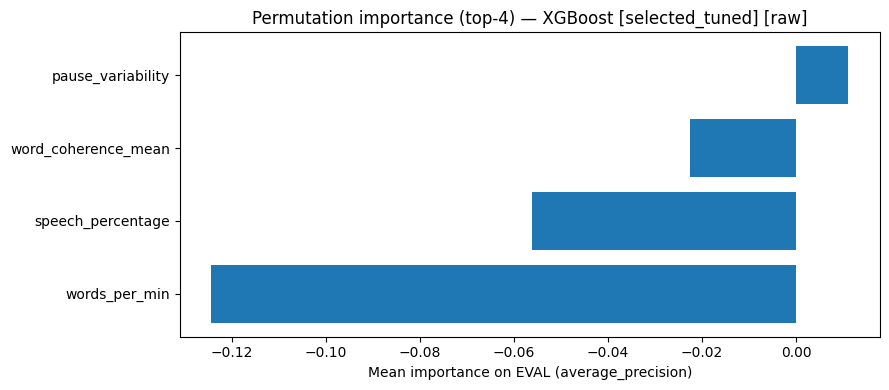


=== Summary metrics on TEST (tuned by PR AUC) ===
    target                   model                  variant  tuned  cv_best_score  cv_pr_auc_mean  cv_pr_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                                selected_cols
PTSD_label      LogisticRegression                     full  False            NaN          0.5219         0.1134                                                                                                                                                                                           219      56              20                  NaN    0.6786    0.6631 0.5281 0.7884        0.6667   0.7442

In [8]:
res_b0_l_ptsd = run_models_pipeline_more_models_tuned_prauc(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_{LANGUAGE}_full{ITERATION}.csv",
    target_col="PTSD_label",
    importance_top_k=5,
)

In [9]:
res_b0_l_ptsd

,target,model,variant,tuned,cv_best_score,cv_pr_auc_mean,cv_pr_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,PTSD_label,LogisticRegression,full,False,NaN,0.521920,0.113378,,219,56,...,0.663102,0.528143,0.788389,0.666667,0.744218,0.593163,0.878912,0.667642,0.207088,
1,PTSD_label,LogisticRegression,"selected(top=5,corr<0.9)",False,NaN,0.514951,0.109552,,219,56,...,0.676923,0.569161,0.792466,0.704762,0.770068,0.628537,0.889796,0.736727,0.193510,"word_coherence_10_mean,phrase_repeat_percentag..."
2,PTSD_label,SVM,full_tuned,True,0.564179,0.564179,0.122966,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",219,56,...,0.609950,0.475936,0.737968,0.614286,0.722449,0.565986,0.859898,0.658134,0.218062,
3,PTSD_label,SVM,selected_tuned,True,0.485991,0.485991,0.136131,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",219,56,...,0.708333,0.588235,0.830131,0.723810,0.798639,0.676190,0.912959,0.720001,0.205175,"turn_length_words,words_per_min,semantic_perpl..."
4,PTSD_label,SGDClassifier(log_loss),full,False,NaN,0.395203,0.081927,,219,56,...,0.544715,0.408122,0.677791,0.561905,0.617687,0.463912,0.756463,0.541740,0.343201,
5,PTSD_label,SGDClassifier(log_loss),"selected(top=5,corr<0.9)",False,NaN,0.420552,0.110023,,219,56,...,0.588104,0.461538,0.696332,0.642857,0.672109,0.529218,0.812347,0.556320,0.331188,"word_coherence_10_mean,mean_pause_length,senti..."
6,PTSD_label,DecisionTree,full_tuned,True,0.395940,0.395940,0.079469,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",219,56,...,0.561878,0.420023,0.697297,0.561905,0.519728,0.369388,0.674150,0.452486,0.366762,
7,PTSD_label,DecisionTree,selected_tuned,True,0.444970,0.444970,0.112335,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",219,56,...,0.390476,0.270833,0.508808,0.390476,0.446259,0.293163,0.588435,0.347835,0.387549,"sentiment_pos,words_per_min,first_person_perce..."
8,PTSD_label,RandomForest,full_tuned,True,0.413951,0.413951,0.083702,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.619910,0.475000,0.754386,0.619048,0.695238,0.538741,0.831293,0.603198,0.208403,
9,PTSD_label,RandomForest,selected_tuned,True,0.390645,0.390645,0.056977,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.494444,0.358429,0.631579,0.495238,0.561905,0.401361,0.714286,0.436155,0.250750,"word_coherence_mean,words_per_min,speech_perce..."


# fusing pipeline

In [2]:
import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Sequence, Dict, Any, List, Tuple
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False


# -------------------------
# Bootstrap CIs (optional; оставил как у тебя)
# -------------------------
def bootstrap_ci_binary(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    metric: str,
    n_boot: int = 2000,
    seed: int = 1706,
    stratified: bool = True,
) -> Tuple[float, float, float]:
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]
    if len(idx_pos) == 0 or len(idx_neg) == 0:
        return float("nan"), float("nan"), float("nan")

    scores = []
    for _ in range(n_boot):
        if stratified:
            samp_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
            samp_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
            idx = np.concatenate([samp_pos, samp_neg])
        else:
            idx = rng.choice(len(y_true), size=len(y_true), replace=True)

        yt, yp, pr = y_true[idx], y_pred[idx], y_proba[idx]
        if metric == "f1_macro":
            s = f1_score(yt, yp, average="macro")
        elif metric == "auc":
            if len(np.unique(yt)) < 2:
                continue
            s = roc_auc_score(yt, pr)
        else:
            raise ValueError("metric must be 'f1_macro' or 'auc'")
        scores.append(s)

    if not scores:
        return float("nan"), float("nan"), float("nan")

    lo, hi = np.percentile(scores, [2.5, 97.5])
    return float(np.mean(scores)), float(lo), float(hi)


# -------------------------
# Clean, leakage-safe late fusion / stacking
# -------------------------
def run_late_fusion_pipeline_clean(
    dataset_b0_path: str,
    dataset_l_path: str,
    *,
    id_col: str = "Participant",
    target_col: str = "PTSD_label",
    split_col: str = "split",
    train_values: Sequence[str] = ("train", "dev"),
    test_value: str = "test",

    # model choice
    base_model_b0: str = "LogisticRegression",
    base_model_l: Optional[str] = None,  # if None -> same as base_model_b0
    meta_C: float = 1.0,

    # leakage-safe drops policy
    drop_demographics: bool = True,          # drop age/gender/sex by default
    extra_drop_common: Optional[Sequence[str]] = None,
    extra_drop_b0: Optional[Sequence[str]] = None,
    extra_drop_l: Optional[Sequence[str]] = None,

    # CV / OOF
    n_splits: int = 5,
    random_state: int = 1706,

    # tuning (if enabled, it will be NESTED in OOF; correct, but slower)
    tune_tree_models: bool = False,
    grid_scoring: str = "average_precision",
    grid_n_jobs: int = 1,
    grid_verbose: int = 0,

    # importance
    compute_importance: bool = True,
    perm_scoring: str = "average_precision",
    perm_n_repeats: int = 10,
    plot_top_k: int = 15,

    # metrics / CIs
    n_boot: int = 2000,
) -> pd.DataFrame:
    """
    What is guaranteed:
      - strict alignment B0<->L by id_col
      - automatic leakage-safe drop based on target_col:
          drops: id_col, split_col, target_col,
                 ALL other *_label / *_severity columns,
                 + optionally demographics
      - base models trained on train+dev; test evaluated on test
      - stacking uses OOF probabilities on train+dev (no test leakage)
      - permutation importance computed on RAW columns (clean and readable)
    """

    if base_model_l is None:
        base_model_l = base_model_b0

    extra_drop_common = list(extra_drop_common or [])
    extra_drop_b0 = list(extra_drop_b0 or [])
    extra_drop_l = list(extra_drop_l or [])

    # ---------- helpers ----------
    def _build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
        cat = [c for c in X.columns if X[c].dtype.name in ["object", "category", "bool"]]
        num = [c for c in X.columns if c not in cat]
        try:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

        return ColumnTransformer(
            transformers=[
                ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", ohe)]), cat),
                ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num),
            ],
            remainder="drop",
        )

    def _safe_n_splits(y: np.ndarray, desired: int) -> int:
        counts = Counter(y.tolist())
        min_class = min(counts.values()) if counts else 0
        return max(2, min(desired, min_class)) if min_class >= 2 else 0

    def _predict_proba(pipe: Pipeline, X: pd.DataFrame) -> np.ndarray:
        return pipe.predict_proba(X)[:, 1]



    def _best_threshold(y_true: np.ndarray, y_proba: np.ndarray, metric: str = "f1") -> float:
        thresholds = np.linspace(0.0, 1.0, 201)
        best_t = 0.5
        best_v = -np.inf
        for t in thresholds:
            y_hat = (y_proba >= t).astype(int)
            if metric == "balanced_acc":
                v = balanced_accuracy_score(y_true, y_hat)
            else:
                v = f1_score(y_true, y_hat, average="macro")
            if v > best_v:
                best_v = v
                best_t = t
        return float(best_t)

    def _metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray) -> Dict[str, Any]:
        out = {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
            "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
            "roc_auc": float(roc_auc_score(y_true, y_proba)) if len(np.unique(y_true)) == 2 else float("nan"),
            "pr_auc": float(average_precision_score(y_true, y_proba)) if len(np.unique(y_true)) == 2 else float("nan"),
            "brier": float(brier_score_loss(y_true, y_proba)),
            "f1_lo": float("nan"),
            "f1_hi": float("nan"),
            "auc_lo": float("nan"),
            "auc_hi": float("nan"),
        }
        # bootstrap CI
        if len(np.unique(y_true)) == 2:
            _, f1_lo, f1_hi = bootstrap_ci_binary(
                y_true, y_pred, y_proba, metric="f1_macro",
                n_boot=n_boot, seed=random_state
            )
            _, auc_lo, auc_hi = bootstrap_ci_binary(
                y_true, y_pred, y_proba, metric="auc",
                n_boot=n_boot, seed=random_state
            )
            out["f1_lo"], out["f1_hi"] = float(f1_lo), float(f1_hi)
            out["auc_lo"], out["auc_hi"] = float(auc_lo), float(auc_hi)
        return out

    def _perm_importance_raw(pipe_fitted: Pipeline, X_eval: pd.DataFrame, y_eval: np.ndarray, title: str) -> pd.DataFrame:
        perm = permutation_importance(
            pipe_fitted, X_eval, y_eval,
            n_repeats=perm_n_repeats,
            random_state=random_state,
            scoring=perm_scoring
        )
        perm_df = pd.DataFrame({
            "feature": list(X_eval.columns),
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

        print(f"\n[{title}] Top-{min(10, len(perm_df))} permutation importances ({perm_scoring}, raw):")
        print(perm_df.head(10).to_string(index=False))

        top_n = min(plot_top_k, len(perm_df))
        if top_n > 0:
            plt.figure(figsize=(9, max(4, 0.35 * top_n)))
            plt.barh(
                perm_df.loc[:top_n - 1, "feature"][::-1],
                perm_df.loc[:top_n - 1, "importance_mean"][::-1],
            )
            plt.title(f"Permutation importance (top-{top_n}) — {title} [raw]")
            plt.xlabel(f"Mean importance on EVAL ({perm_scoring})")
            plt.tight_layout()
            plt.show()

        return perm_df

    def _make_leakage_drop(df: pd.DataFrame) -> List[str]:
        # drop: id, split, target + all other *_label / *_severity columns
        drops = {id_col, split_col, target_col}

        for c in df.columns:
            lc = str(c).lower()
            if c == target_col:
                continue
            if lc.endswith("_label") or lc.endswith("_severity"):
                drops.add(c)

        if drop_demographics:
            for c in ["age", "gender", "sex"]:
                if c in df.columns:
                    drops.add(c)

        for c in extra_drop_common:
            if c in df.columns:
                drops.add(c)

        return sorted(drops)

    def _assert_no_leakage_cols(X: pd.DataFrame, df_ref: pd.DataFrame, where: str) -> None:
        forbidden = set(_make_leakage_drop(df_ref)) - {id_col, split_col}
        bad = forbidden.intersection(set(X.columns))
        if bad:
            raise ValueError(
                f"[LEAKAGE] Forbidden columns present in features at {where}: {sorted(bad)}. "
                f"Check drop policy / extra_drop_*."
            )

    def _get_estimator_and_grid(model_name: str, y_for_xgb: np.ndarray):
        name = model_name.strip()

        if name == "LogisticRegression":
            est = LogisticRegression(
                solver="lbfgs", max_iter=5000, class_weight="balanced",
                random_state=random_state
            )
            return est, {}

        if name in ["SVM", "SVC"]:
            est = SVC(
                kernel="rbf", C=1.0, gamma="scale", probability=True,
                class_weight="balanced", random_state=random_state
            )
            grid = {
                "C": [0.1, 1, 10],
                "gamma": ["scale", "auto"],
                "kernel": ["rbf", "linear"],
            }
            return est, grid

        if name == "SGDClassifier(log_loss)":
            est = SGDClassifier(
                loss="log_loss", penalty="l2", alpha=1e-4,
                max_iter=5000, tol=1e-3, class_weight="balanced",
                random_state=random_state
            )
            return est, {}

        if name == "DecisionTree":
            est = DecisionTreeClassifier(random_state=random_state, class_weight="balanced")
            grid = {
                "max_depth": [3, 5, 10, None],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4, 8],
            }
            return est, grid

        if name == "RandomForest":
            est = RandomForestClassifier(random_state=random_state, class_weight="balanced", n_jobs=1)
            grid = {
                "n_estimators": [200, 500],
                "max_depth": [None, 5, 10],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4],
                "max_features": ["sqrt", "log2", 0.5],
                "bootstrap": [True],
            }
            return est, grid

        if name == "XGBoost":
            if not xgb_available:
                raise RuntimeError("XGBoost requested but xgboost is not installed.")
            pos = int((y_for_xgb == 1).sum())
            neg = int((y_for_xgb == 0).sum())
            spw = float(neg / max(pos, 1)) if pos > 0 else 1.0
            est = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=random_state,
                n_jobs=1,
                scale_pos_weight=spw,
            )
            grid = {
                "n_estimators": [200, 500],
                "max_depth": [3, 6, 10],
                "learning_rate": [0.03, 0.1],
                "subsample": [0.8, 1.0],
                "colsample_bytree": [0.8, 1.0],
                "min_child_weight": [1, 5],
                "reg_lambda": [1.0, 5.0],
            }
            return est, grid

        raise ValueError(
            f"Unknown model '{model_name}'. Use: LogisticRegression, SGDClassifier(log_loss), "
            f"DecisionTree, RandomForest, XGBoost"
        )

    def _fit_with_optional_tuning(pipe: Pipeline, grid: Dict[str, List[Any]], X_tr: pd.DataFrame, y_tr: np.ndarray) -> Tuple[Pipeline, Dict[str, Any], float, bool]:
        # tuning only for models that have a non-empty grid AND if enabled
        if (not tune_tree_models) or (not grid):
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        k = _safe_n_splits(y_tr, n_splits)
        if k < 2:
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        gs = GridSearchCV(
            estimator=pipe,
            param_grid={f"clf__{k}": v for k, v in grid.items()},
            scoring=grid_scoring,
            cv=cv,
            n_jobs=grid_n_jobs,
            refit=True,
            verbose=grid_verbose,
            error_score=np.nan,
        )
        gs.fit(X_tr, y_tr)
        return gs.best_estimator_, gs.best_params_, float(gs.best_score_), True

    def _oof_proba_nested(
        model_name: str,
        X: pd.DataFrame,
        y: np.ndarray
    ) -> np.ndarray:
        """
        OOF probabilities on train+dev.
        Если tune_tree_models=True и для модели есть grid -> nested tuning внутри каждого фолда (корректно).
        """
        k = _safe_n_splits(y, n_splits)
        if k < 2:
            raise ValueError(
                f"Not enough samples per class for CV. "
                f"Counts={Counter(y.tolist())}. Reduce n_splits or get more data."
            )

        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        oof = np.empty(len(y), dtype=float)

        for tr_idx, val_idx in cv.split(X, y):
            X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
            X_val = X.iloc[val_idx]

            est, grid = _get_estimator_and_grid(model_name, y_tr)
            pipe = Pipeline([("pre", _build_preprocessor(X_tr)), ("clf", clone(est))])

            # nested tuning
            pipe_best, _, _, _ = _fit_with_optional_tuning(pipe, grid, X_tr, y_tr)
            oof[val_idx] = _predict_proba(pipe_best, X_val)

        return oof

    def _fit_final_and_eval(
        title: str,
        model_name: str,
        X_tr: pd.DataFrame,
        y_tr: np.ndarray,
        X_te: pd.DataFrame,
        y_te: np.ndarray,
        df_ref_for_drop: pd.DataFrame,
    ) -> Dict[str, Any]:
        est, grid = _get_estimator_and_grid(model_name, y_tr)
        pipe = Pipeline([("pre", _build_preprocessor(X_tr)), ("clf", clone(est))])

        pipe_best, best_params, best_cv, tuned = _fit_with_optional_tuning(pipe, grid, X_tr, y_tr)

        p_te = _predict_proba(pipe_best, X_te)
        y_pred = (p_te >= 0.5).astype(int)

        print(f"\n=== {title}: {model_name} [{'tuned' if tuned else 'default'}] ===")
        if tuned:
            print("Best CV score:", round(best_cv, 4))
            print("Best params:", best_params)

        print("\nClassification report:\n", classification_report(y_te, y_pred, digits=3))
        print("Confusion matrix:\n", confusion_matrix(y_te, y_pred))

        perm_df = None
        if compute_importance:
            _assert_no_leakage_cols(X_tr, df_ref_for_drop, where=f"{title}/train")
            _assert_no_leakage_cols(X_te, df_ref_for_drop, where=f"{title}/test")
            perm_df = _perm_importance_raw(pipe_best, X_te, y_te, f"{title} ({model_name})")

        out = {
            "title": title,
            "model": model_name,
            "tuned": bool(tuned),
            "cv_best_score": float(best_cv),
            "best_params": str(best_params) if best_params else "",
            "n_train": int(len(y_tr)),
            "n_test": int(len(y_te)),
            "n_features_raw": int(X_tr.shape[1]),
            "pipe_final": pipe_best,
            "proba_test": p_te,
            "y_pred_test": y_pred,
            "perm_df": perm_df,
            **_metrics(y_te, y_pred, p_te),
        }
        return out

    # ---------- load + align ----------
    df_b0 = pd.read_csv(dataset_b0_path)
    df_l = pd.read_csv(dataset_l_path)

    # enforce string ids (safe for sorting)
    if id_col in df_b0.columns:
        df_b0[id_col] = df_b0[id_col].astype(str)
    if id_col in df_l.columns:
        df_l[id_col] = df_l[id_col].astype(str)

    if id_col not in df_b0.columns or id_col not in df_l.columns:
        raise KeyError(f"'{id_col}' must exist in both datasets for reliable fusion alignment.")

    common = sorted(set(df_b0[id_col]).intersection(set(df_l[id_col])))
    if len(common) == 0:
        raise ValueError(f"No overlapping '{id_col}' values between B0 and L datasets.")

    df_b0 = df_b0[df_b0[id_col].isin(common)].sort_values(id_col).reset_index(drop=True)
    df_l = df_l[df_l[id_col].isin(common)].sort_values(id_col).reset_index(drop=True)

    # strict asserts like in clean script
    if not np.array_equal(df_b0[id_col].values, df_l[id_col].values):
        raise ValueError("Alignment failed: id ordering mismatch after sorting/intersection.")
    if split_col not in df_b0.columns or split_col not in df_l.columns:
        raise KeyError(f"Missing '{split_col}' in one of datasets.")
    if target_col not in df_b0.columns or target_col not in df_l.columns:
        raise KeyError(f"Missing target '{target_col}' in one of datasets.")

    if not np.array_equal(df_b0[split_col].astype(str).values, df_l[split_col].astype(str).values):
        raise ValueError(f"Mismatch between B0 and L for column '{split_col}' after alignment.")
    if not np.array_equal(df_b0[target_col].astype(int).values, df_l[target_col].astype(int).values):
        raise ValueError(f"Mismatch between B0 and L for column '{target_col}' after alignment.")

    # ---------- train/dev vs test ----------
    split_lower = df_b0[split_col].astype(str).str.lower().str.strip()
    train_values_set = {str(v).lower() for v in train_values}
    is_train = split_lower.isin(train_values_set)
    is_test = split_lower.eq(str(test_value).lower())

    if is_train.sum() == 0 or is_test.sum() == 0:
        raise ValueError(
            f"Train/Test rows not found. train in {sorted(train_values_set)} count={is_train.sum()}, "
            f"test='{test_value}' count={is_test.sum()}."
        )

    y_train = df_b0.loc[is_train, target_col].astype(int).to_numpy()
    y_test = df_b0.loc[is_test, target_col].astype(int).to_numpy()

    # ---------- automatic leakage-safe drops ----------
    drop_common_b0 = _make_leakage_drop(df_b0)
    drop_common_l = _make_leakage_drop(df_l)
    drop_common = sorted(set(drop_common_b0).union(set(drop_common_l)))

    # apply extras
    drop_b0 = sorted(set(drop_common).union(set(extra_drop_b0)))
    drop_l = sorted(set(drop_common).union(set(extra_drop_l)))

    X_b0_train = df_b0.loc[is_train].drop(columns=drop_b0, errors="ignore")
    X_b0_test = df_b0.loc[is_test].drop(columns=drop_b0, errors="ignore")

    X_l_train = df_l.loc[is_train].drop(columns=drop_l, errors="ignore")
    X_l_test = df_l.loc[is_test].drop(columns=drop_l, errors="ignore")

    if X_b0_train.shape[1] == 0:
        raise ValueError("B0 features empty after dropping columns.")
    if X_l_train.shape[1] == 0:
        raise ValueError("L features empty after dropping columns.")

    # hard leakage asserts (ключевой фикс)
    _assert_no_leakage_cols(X_b0_train, df_b0, where="B0/train")
    _assert_no_leakage_cols(X_b0_test, df_b0, where="B0/test")
    _assert_no_leakage_cols(X_l_train, df_l, where="L/train")
    _assert_no_leakage_cols(X_l_test, df_l, where="L/test")

    # ---------- fit base models (train+dev -> test) ----------
    b0_out = _fit_final_and_eval(
        "B0 base", base_model_b0, X_b0_train, y_train, X_b0_test, y_test, df_b0
    )
    l_out = _fit_final_and_eval(
        "L base", base_model_l, X_l_train, y_train, X_l_test, y_test, df_l
    )

    # ---------- OOF probs for meta (clean stacking) ----------
    p_b0_oof = _oof_proba_nested(base_model_b0, X_b0_train, y_train)
    p_l_oof = _oof_proba_nested(base_model_l, X_l_train, y_train)

    X_meta_train = np.column_stack([p_b0_oof, p_l_oof])
    X_meta_test = np.column_stack([b0_out["proba_test"], l_out["proba_test"]])

    meta = LogisticRegression(
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        C=float(meta_C),
        random_state=random_state,
    )
    meta.fit(X_meta_train, y_train)

    p_fused = meta.predict_proba(X_meta_test)[:, 1]
    # best_t = _best_threshold(y_test, p_fused, metric="f1")
    # y_fused = (p_fused >= best_t).astype(int)
    # print("Best threshold (F1):", best_t)
    y_fused = (p_fused >= 0.5).astype(int)

    print("\n=== FUSED (meta LogisticRegression on [p_B0, p_L]) ===")
    print("Meta weights:", {
        "intercept": float(meta.intercept_[0]),
        "w_pB0": float(meta.coef_[0, 0]),
        "w_pL": float(meta.coef_[0, 1]),
    })
    print("\nClassification report:\n", classification_report(y_test, y_fused, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_fused))

    plt.figure(figsize=(6, 4))
    plt.barh(["p_B0", "p_L"], [meta.coef_[0, 0], meta.coef_[0, 1]])
    plt.title("Meta LogisticRegression coefficients")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

    fused_metrics = _metrics(y_test, y_fused, p_fused)

    # ---------- summary table ----------
    rows = []
    for out in [b0_out, l_out]:
        rows.append({
            "stage": out["title"],
            "model": out["model"],
            "tuned": out["tuned"],
            "cv_best_score": out["cv_best_score"],
            "best_params": out["best_params"],
            "n_train": out["n_train"],
            "n_test": out["n_test"],
            "n_features_raw": out["n_features_raw"],
            **{k: out[k] for k in [
                "accuracy", "f1_macro", "f1_lo", "f1_hi",
                "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
                "pr_auc", "brier"
            ]},
        })

    rows.append({
        "stage": "FUSED",
        "model": "MetaLogisticRegression",
        "tuned": False,
        "cv_best_score": float("nan"),
        "best_params": f"meta_C={meta_C}",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "n_features_raw": 2,
        **fused_metrics,
    })

    res_df = pd.DataFrame(rows)[[
        "stage", "model", "tuned", "cv_best_score", "best_params",
        "n_train", "n_test", "n_features_raw",
        "accuracy", "f1_macro", "f1_lo", "f1_hi",
        "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
        "pr_auc", "brier",
    ]]

    print("\n=== Summary metrics on TEST (tuned by PR AUC) ===")
    print(res_df.round(4).to_string(index=False))

    return res_df


# -------------------------
# Example usage
# -------------------------
# res = run_late_fusion_pipeline_clean(
#     dataset_b0_path="/mnt/data/dataset_B0_gemma_eng_test_small.csv",
#     dataset_l_path="/mnt/data/dataset_L_gemma_eng_add_small.csv",
#     target_col="PTSD_label",
#     base_model_b0="LogisticRegression",
#     base_model_l="LogisticRegression",
#     tune_tree_models=False,
#     compute_importance=True
# )



=== B0 base: LogisticRegression [default] ===

Classification report:
               precision    recall  f1-score   support

           0      0.875     0.600     0.712        35
           1      0.562     0.857     0.679        21

    accuracy                          0.696        56
   macro avg      0.719     0.729     0.696        56
weighted avg      0.758     0.696     0.700        56

Confusion matrix:
 [[21 14]
 [ 3 18]]

[B0 base (LogisticRegression)] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.331320        0.032650
       turn_length_words         0.232496        0.077764
  word_repeat_percentage         0.107529        0.071210
           words_per_min         0.069432        0.029875
       pause_variability         0.061503        0.049599
       mean_pause_length         0.047132        0.058671
       speech_percentage         0.029517        0.034834


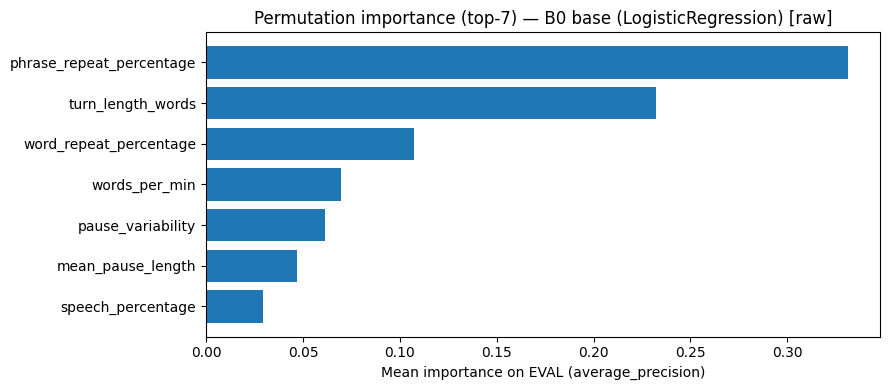


=== L base: LogisticRegression [default] ===

Classification report:
               precision    recall  f1-score   support

           0      0.750     0.771     0.761        35
           1      0.600     0.571     0.585        21

    accuracy                          0.696        56
   macro avg      0.675     0.671     0.673        56
weighted avg      0.694     0.696     0.695        56

Confusion matrix:
 [[27  8]
 [ 9 12]]

[L base (LogisticRegression)] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
              semantic_perplexity_mean         0.139764        0.023553
                     sentiment_overall         0.077973        0.030321
                              mattr_10         0.072071        0.015939
                word_coherence_10_mean         0.061790        0.036659
                     syllables_per_min         0.055173        0.018836
                         sentiment_pos      

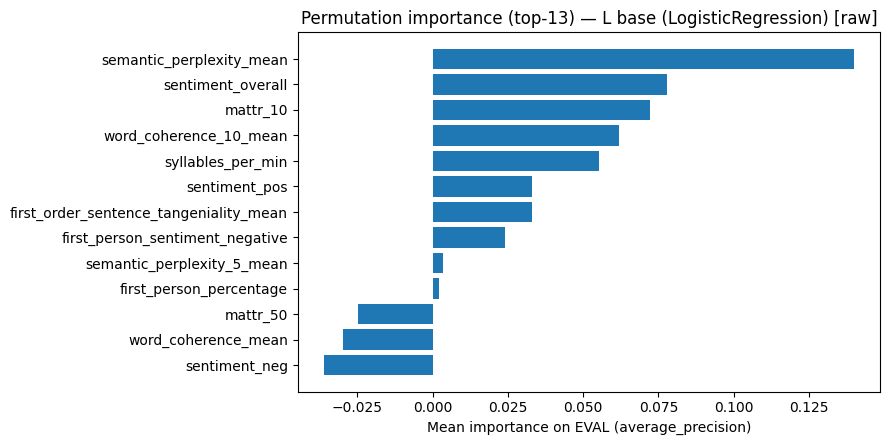


=== FUSED (meta LogisticRegression on [p_B0, p_L]) ===
Meta weights: {'intercept': -1.405851934041265, 'w_pB0': 1.6285526418503953, 'w_pL': 1.2282479517820684}

Classification report:
               precision    recall  f1-score   support

           0      0.828     0.686     0.750        35
           1      0.593     0.762     0.667        21

    accuracy                          0.714        56
   macro avg      0.710     0.724     0.708        56
weighted avg      0.739     0.714     0.719        56

Confusion matrix:
 [[24 11]
 [ 5 16]]


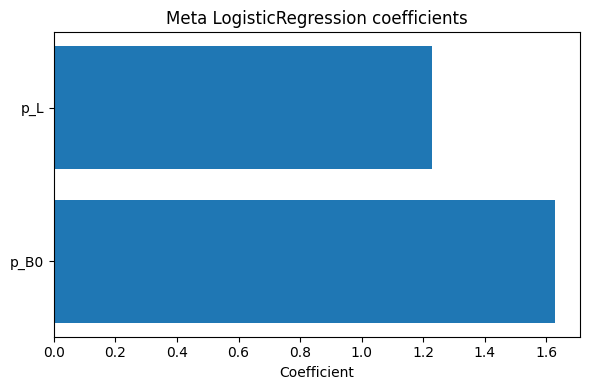


=== Summary metrics on TEST (tuned by PR AUC) ===
  stage                  model  tuned  cv_best_score best_params  n_train  n_test  n_features_raw  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier
B0 base     LogisticRegression  False            NaN                  219      56               7    0.6964    0.6956 0.5828 0.8020        0.7286   0.7796  0.6435  0.9034  0.7090 0.2120
 L base     LogisticRegression  False            NaN                  219      56              13    0.6964    0.6730 0.5359 0.7924        0.6714   0.6939  0.5401  0.8300  0.5651 0.2204
  FUSED MetaLogisticRegression  False            NaN  meta_C=1.0      219      56               2    0.7143    0.7083 0.5828 0.8177        0.7238   0.8204  0.6871  0.9293  0.7947 0.2137


In [3]:
res = run_late_fusion_pipeline_clean(
    dataset_b0_path=f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_{LANGUAGE}_small_test{ITERATION}.csv",
    dataset_l_path=f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_{LANGUAGE}_small_test{ITERATION}.csv",
    base_model_b0="LogisticRegression",
    base_model_l="LogisticRegression",
    tune_tree_models=False,
    compute_importance=True,
    # feature_selection=False,  # set True to do train-only raw-column selection per modality
    target_col='PTSD_label',
)

In [4]:
res

,stage,model,tuned,cv_best_score,best_params,n_train,n_test,n_features_raw,accuracy,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier
0,B0 base,LogisticRegression,False,NaN,,219,56,7,0.696429,0.695555,0.582766,0.801993,0.728571,0.779592,0.643503,0.903401,0.708995,0.211972
1,L base,LogisticRegression,False,NaN,,219,56,13,0.696429,0.672965,0.535851,0.792383,0.671429,0.693878,0.540102,0.829966,0.565055,0.220411
2,FUSED,MetaLogisticRegression,False,NaN,meta_C=1.0,219,56,2,0.714286,0.708333,0.582766,0.817708,0.723810,0.820408,0.687075,0.929252,0.794683,0.213731
